In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configurar directorios
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.chdir('TFMDS')
else:
    if os.path.exists('/workspaces/TFMDS'):
        os.chdir('/workspaces/TFMDS')
    else:
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f"Directorio de trabajo: {os.getcwd()}")

# Configurar estilos visuales
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

Directorio de trabajo: /workspaces/TFMDS


# CARGA Y CONSOLIDACIÓN DE RESULTADOS

In [2]:
# ============================================================================
# CARGAR TODOS LOS FICHEROS DE RESULTADOS DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("📂 CARGANDO RESULTADOS DE MÉTRICAS DE TODOS LOS MODELOS")
print("="*100)

# Directorio de datos
datos_dir = 'datos'

# Buscar todos los archivos CSV que contengan 'resultados_metricas'
archivos_metricas = [f for f in os.listdir(datos_dir) if f.startswith('resultados_metricas') and f.endswith('.csv')]

# Cargar y consolidar todos los resultados en un único DataFrame
dfs_resultados = []
for archivo in archivos_metricas:
    ruta = os.path.join(datos_dir, archivo)
    df_temp = pd.read_csv(ruta)
    dfs_resultados.append(df_temp)
    print(f"{archivo}: {len(df_temp)} registros")

# Consolidar en un único DataFrame
df_resultados_consolidados = pd.concat(dfs_resultados, ignore_index=True)

print(f"\n📊 ESTADÍSTICAS DEL DATASET CONSOLIDADO:")
print(f"   Total de registros: {len(df_resultados_consolidados)}")
print(f"   Total de algoritmos únicos: {df_resultados_consolidados['Algoritmo'].nunique()}")
print(f"   Algoritmos: {sorted(df_resultados_consolidados['Algoritmo'].unique())}")
print(f"\n   Distribución por NDetalle:")
print(df_resultados_consolidados['NDetalle'].value_counts())

# Mostrar primeras y últimas filas
print(f"\n📋 Primeras filas del dataset consolidado:")
print(df_resultados_consolidados.head(10))

# Información sobre los datos
print(f"\n📌 Información del dataset:")
print(f"   Columnas: {list(df_resultados_consolidados.columns)}")
print(f"   Tipos de datos:\n{df_resultados_consolidados.dtypes}")
print(f"\n   Valores faltantes:\n{df_resultados_consolidados.isnull().sum()}")


📂 CARGANDO RESULTADOS DE MÉTRICAS DE TODOS LOS MODELOS
resultados_metricas_xgboost.csv: 33 registros
resultados_metricas_lightgbm.csv: 33 registros
resultados_metricas_gru.csv: 25 registros
resultados_metricas_nbeats.csv: 25 registros
resultados_metricas_transformer_gpu.csv: 25 registros
resultados_metricas_catboost.csv: 33 registros
resultados_metricas_lstm.csv: 25 registros
resultados_metricas_TFT_gpu.csv: 25 registros
resultados_metricas_deepar.csv: 25 registros
resultados_metricas_rf.csv: 33 registros
resultados_metricas_baseline.csv: 26 registros

📊 ESTADÍSTICAS DEL DATASET CONSOLIDADO:
   Total de registros: 308
   Total de algoritmos únicos: 12
   Algoritmos: ['CatBoost', 'DEEPAR', 'GRU', 'LSTM', 'LightGBM', 'MEDIA7', 'NAIVE', 'NBEATS', 'RF', 'TFT_GPU', 'TRSFMER', 'XGBoost']

   Distribución por NDetalle:
NDetalle
Global      156
Cluster     120
Producto     32
Name: count, dtype: int64

📋 Primeras filas del dataset consolidado:
  Algoritmo NDetalle  Cluster  Producto    MAE   

# DEFINICIÓN DE MÉTRICAS Y FUNCIONES DE COMPARACIÓN

In [3]:
# ============================================================================
# DEFINIR MÉTRICAS PARA COMPARACIÓN Y DIRECCIONES (LOWER/HIGHER IS BETTER)
# ============================================================================

# Lista de métricas principales para comparación
METRICAS_COMPARACION = ['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']

# Direcciones: True = más alto es mejor, False = más bajo es mejor
METRIC_DIRECTIONS = {
    'MAE': False,           # Más bajo es mejor
    'MSE': False,
    'RMSE': False,
    'R2': True,             # Más alto es mejor
    'MAPE (%)': False,
    'SMAPE (%)': False,
    'RMSSE': False,
    'MAE (%)': False
}

# Colores para visualizaciones
COLOR_BEST = '#2ecc71'    # Verde (mejor)
COLOR_WORST = '#e74c3c'   # Rojo (peor)
COLOR_NEUTRAL = '#ecf0f1' # Gris neutral

print("\n" + "="*100)
print("📊 CONFIGURACIÓN DE MÉTRICAS PARA COMPARACIÓN")
print("="*100)
print(f"\n✅ Métricas seleccionadas: {METRICAS_COMPARACION}")
print(f"\n📌 Direcciones de mejora:")
for metrica, direccion in METRIC_DIRECTIONS.items():
    print(f"   {metrica:15s}: {'↑ Más alto es mejor' if direccion else '↓ Más bajo es mejor'}")

# Función para formatear tabla con colores
def colorear_fila(row, columnas_metricas, metric_directions):
    """Aplica colores a las celdas basado en mejor/peor desempeño"""
    resultado = [''] * len(row)
    
    for col in columnas_metricas:
        if col not in row.index or pd.isna(row[col]):
            continue
        
        # Obtener valores válidos (no NaN) para la columna
        valores_validos = df_comparacion[col].dropna()
        
        if len(valores_validos) == 0:
            continue
        
        valor = row[col]
        es_mejor = metric_directions.get(col, False)
        
        # Determinar si es el mejor o peor valor
        if es_mejor:
            # Más alto es mejor
            es_optimo = valor == valores_validos.max()
            es_pesimo = valor == valores_validos.min()
        else:
            # Más bajo es mejor
            es_optimo = valor == valores_validos.min()
            es_pesimo = valor == valores_validos.max()
        
        # Aplicar colores
        col_idx = list(row.index).index(col)
        if es_optimo:
            resultado[col_idx] = f'background-color: {COLOR_BEST}'
        elif es_pesimo:
            resultado[col_idx] = f'background-color: {COLOR_WORST}'
    
    return resultado

print("\n✅ Funciones de formato configuradas")


📊 CONFIGURACIÓN DE MÉTRICAS PARA COMPARACIÓN

✅ Métricas seleccionadas: ['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']

📌 Direcciones de mejora:
   MAE            : ↓ Más bajo es mejor
   MSE            : ↓ Más bajo es mejor
   RMSE           : ↓ Más bajo es mejor
   R2             : ↑ Más alto es mejor
   MAPE (%)       : ↓ Más bajo es mejor
   SMAPE (%)      : ↓ Más bajo es mejor
   RMSSE          : ↓ Más bajo es mejor
   MAE (%)        : ↓ Más bajo es mejor

✅ Funciones de formato configuradas


| Métrica | Ventajas | Desventajas |
| :--- | :--- | :--- |
| **MAE** (Error Absoluto Medio) | Es fácil de interpretar ya que devuelve valores en las unidades originales. Es una métrica simétrica, sin sesgos hacia la sobre o subestimación. | Es dependiente de la escala, lo que puede sesgar la métrica a favor de series temporales de gran escala al agregar o comparar. |
| **MSE** (Error Cuadrático Medio) | Se utiliza comúnmente como función de pérdida para problemas de regresión,. Es simétrico, sin sesgos hacia la sobre o subestimación,. **Ventaja/Desventaja:** Penaliza fuertemente los errores grandes. | Sus unidades son al cuadrado, lo que lo hace menos interpretable,. Puede inflar el impacto de errores atípicos o marginales. |
| **RMSE** (Raíz del Error Cuadrático Medio) | Es más interpretable que el MSE porque se presenta en la misma escala que la entrada original. Penaliza fuertemente los errores grandes. Es una métrica simétrica, sin sesgos hacia la sobre o subestimación. | Es dependiente de la escala. |
| **R2** (Coeficiente de Determinación) | Es una medida estadística que cuantifica qué tan bien el modelo explica la variación en la variable objetivo,. Los valores más altos indican un mejor rendimiento. | Un valor excesivamente alto puede ser un signo de sobreajuste. |
| **MAPE (%)** (Error Porcentual Absoluto Medio) | Expresa la precisión como un porcentaje, lo que permite la comparación de pronósticos de diferentes series en distintas escalas. Es útil para comprender el error de predicción relativo. | **No está definido cuando el valor real es cero**,. Es asimétrico, favoreciendo la subestimación, lo que puede llevar a pronósticos conservadores y a un posible desabastecimiento. |
| **SMAPE (%)** (Error Porcentual Absoluto Medio Simétrico) | Expresa el error como un porcentaje, útil para comparar modelos. Fue propuesto para intentar evitar la asimetría del MAPE. | **Es inherentemente asimétrico**, favoreciendo fuertemente la sobrestimación. |
| **RMSSE** (Raíz del Error Cuadrático Medio Escalonado) | Escala el error de pronóstico utilizando el MAE de un pronóstico ingenuo (línea base). Esto facilita la comparación del rendimiento del modelo entre diferentes series. Es imparcial con respecto a la sobre o subestimación. | Su cálculo se basa en el error cuadrado, lo que puede amplificar el impacto de los errores grandes. |
| **MAE (%)** (Error Absoluto Medio en Porcentaje) | Es útil para calcular medidas agregadas en un conjunto de datos de series temporales. Puede superar el sesgo del MAPE hacia la subestimación. | Es una métrica no independiente de la escala, por lo que se sesga hacia las series de gran escala. |

# MODELOS GLOBALES

## Métricas modelos globales

In [4]:
# ============================================================================
# COMPARATIVA GLOBAL - NIVEL AGREGADO (todos los clusters y productos)
# ============================================================================

print("\n" + "="*100)
print("🌍 COMPARATIVA GLOBAL - RENDIMIENTO POR ALGORITMO (Nivel Agregado)")
print("="*100)

# Filtrar solo registros GLOBAL
df_global = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].isna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Seleccionar columnas relevantes para comparación
columnas_display = ['Algoritmo'] + METRICAS_COMPARACION
df_comparacion = df_global[columnas_display].sort_values('RMSE').reset_index(drop=True)

print(f"\n📊 Resultados globales ({len(df_comparacion)} algoritmos):")

# Aplicar estilos con colores (usando funciones de pandas styling)
display_style = df_comparacion.style
for col in METRICAS_COMPARACION:
    if col in df_comparacion.columns:
        es_mejor = METRIC_DIRECTIONS.get(col, False)
        if es_mejor:
            # Más alto es mejor
            display_style = display_style.highlight_max(subset=[col], color=COLOR_BEST)
            display_style = display_style.highlight_min(subset=[col], color=COLOR_WORST)
        else:
            # Más bajo es mejor
            display_style = display_style.highlight_min(subset=[col], color=COLOR_BEST)
            display_style = display_style.highlight_max(subset=[col], color=COLOR_WORST)

# Mostrar la tabla sin la columna de índice
from IPython.display import HTML
display(display_style.format(precision=4).hide(axis='index'))


🌍 COMPARATIVA GLOBAL - RENDIMIENTO POR ALGORITMO (Nivel Agregado)

📊 Resultados globales (12 algoritmos):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,1.5715,2.3682,0.2682,49.5700,144.5600
LightGBM,1.5641,2.3684,0.2680,49.7100,144.8200
XGBoost,1.5662,2.3723,0.2656,49.8300,144.6400
RF,1.5905,2.4020,0.2471,48.9200,143.9500
DEEPAR,1.4573,2.5380,0.1594,63.3300,150.4600
LSTM,1.4428,2.5584,0.1458,67.3600,157.4000
TFT_GPU,1.4151,2.5697,0.1383,66.0500,163.0000
TRSFMER,1.4062,2.5959,0.1207,64.0200,163.8400
GRU,1.4104,2.6169,0.1064,72.8600,162.2500
NBEATS,1.4610,2.7387,0.0212,76.3000,169.2200


In [5]:
# ============================================================================
# GRÁFICO: COMPARATIVA DE ALGORITMOS - MÉTRICA PARAMETRIZABLE
# ============================================================================

# PARÁMETRO: Métrica a visualizar (cambiar aquí para ver otra métrica)
METRICA_GRAFICO = 'RMSE'

# Algoritmos a excluir del gráfico
ALGORITMOS_EXCLUIR_GRAFICO = ['NAIVE', 'MEDIA7']

print("\n" + "="*100)
print(f"📊 GRÁFICO: COMPARATIVA DE ALGORITMOS - {METRICA_GRAFICO}")
print("="*100)

# Obtener datos globales (NDetalle == 'Global', sin Cluster, sin Producto)
df_global_para_grafico = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].isna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Filtrar algoritmos a excluir
df_grafico_data = df_global_para_grafico[
    ~df_global_para_grafico['Algoritmo'].isin(ALGORITMOS_EXCLUIR_GRAFICO)
].copy()

# Ordenar por la métrica seleccionada
df_grafico_data = df_grafico_data.sort_values(METRICA_GRAFICO)

# Crear gráfico de barras
import plotly.express as px

fig = px.bar(
    df_grafico_data,
    x='Algoritmo',
    y=METRICA_GRAFICO,
    title=f'Comparativa de Algoritmos por {METRICA_GRAFICO}',
    labels={'Algoritmo': 'Algoritmo', METRICA_GRAFICO: METRICA_GRAFICO},
    color=METRICA_GRAFICO,
    color_continuous_scale='RdYlGn_r',
    text=METRICA_GRAFICO,
    height=500
)

fig.update_traces(textposition='auto', texttemplate='%{text:.4f}')
fig.update_layout(
    xaxis_title='Algoritmo',
    yaxis_title=METRICA_GRAFICO,
    showlegend=False,
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

print(f"\n✅ Gráfico generado con {len(df_grafico_data)} algoritmos (excluidos: {', '.join(ALGORITMOS_EXCLUIR_GRAFICO)})")
print(f"💡 Tip: Cambia METRICA_GRAFICO = '{METRICA_GRAFICO}' por otra métrica para ver diferentes comparativas")


📊 GRÁFICO: COMPARATIVA DE ALGORITMOS - RMSE



✅ Gráfico generado con 10 algoritmos (excluidos: NAIVE, MEDIA7)
💡 Tip: Cambia METRICA_GRAFICO = 'RMSE' por otra métrica para ver diferentes comparativas


## Métricas modelos globales respecto cada cluster

In [6]:
# ============================================================================
# COMPARATIVA POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🎯 COMPARATIVA POR CLUSTER")
print("="*100)

# Obtener clusters únicos en los datos globales (donde Cluster no es NaN)
df_por_cluster = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

clusters_unicos = sorted(df_por_cluster['Cluster'].unique())

# Crear una tabla comparativa para cada cluster
for cluster in clusters_unicos:
    print(f"\n{'='*100}")
    print(f"📊 CLUSTER {int(cluster) if not pd.isna(cluster) else 'N/A'}")
    print(f"{'='*100}")
    
    df_cluster_data = df_por_cluster[df_por_cluster['Cluster'] == cluster]
    columnas_display = ['Algoritmo'] + METRICAS_COMPARACION
    
    df_cluster_comparacion = df_cluster_data[columnas_display].sort_values('RMSE')
    
    if len(df_cluster_comparacion) == 0:
        print(f"⚠️ Sin datos para este cluster")
        continue
    
    # Aplicar colores
    display_style_cluster = df_cluster_comparacion.style
    for col in METRICAS_COMPARACION:
        if col in df_cluster_comparacion.columns:
            es_mejor = METRIC_DIRECTIONS.get(col, False)
            if es_mejor:
                display_style_cluster = display_style_cluster.highlight_max(subset=[col], color=COLOR_BEST)
                display_style_cluster = display_style_cluster.highlight_min(subset=[col], color=COLOR_WORST)
            else:
                display_style_cluster = display_style_cluster.highlight_min(subset=[col], color=COLOR_BEST)
                display_style_cluster = display_style_cluster.highlight_max(subset=[col], color=COLOR_WORST)
    
    display(display_style_cluster.format(precision=4).hide(axis='index'))


🎯 COMPARATIVA POR CLUSTER

📊 CLUSTER 0


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
RF,1.8134,2.5458,0.1195,39.2900,125.2200
LightGBM,1.7919,2.5489,0.1174,40.1000,126.2800
XGBoost,1.7972,2.5525,0.1149,40.3900,126.2000
CatBoost,1.8071,2.5566,0.1120,40.4400,126.1400
TFT_GPU,1.7447,2.6994,0.0101,50.5500,137.0200
LSTM,1.7659,2.7315,-0.0137,55.9000,141.6800
DEEPAR,1.7792,2.7340,-0.0155,55.5100,138.2400
TRSFMER,1.7191,2.7649,-0.0386,53.3700,145.6900
GRU,1.7498,2.8569,-0.1088,64.3700,151.7500
NBEATS,1.8001,2.9631,-0.1928,74.9400,163.8400



📊 CLUSTER 1


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,2.7635,3.5794,0.1478,55.2200,98.8100
LightGBM,2.7725,3.5917,0.1419,55.3100,99.1500
XGBoost,2.7724,3.5930,0.1413,56.0700,99.0500
RF,2.8023,3.5957,0.1400,55.6100,98.3300
GRU,2.7840,3.8088,0.0351,51.5100,103.7600
LSTM,2.8403,3.8699,0.0039,51.0300,105.4900
TFT_GPU,2.7751,3.9089,-0.0163,51.9200,104.2800
DEEPAR,2.8537,3.9121,-0.0180,54.5900,107.7900
TRSFMER,2.7866,4.0084,-0.0687,50.7300,110.4900
NBEATS,3.0061,4.2800,-0.2184,57.0500,121.3200



📊 CLUSTER 2


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
LightGBM,3.6213,5.0764,0.2036,72.9000,81.0300
CatBoost,3.6116,5.0976,0.1970,72.1000,80.8300
RF,3.6959,5.1090,0.1934,73.6900,80.3700
XGBoost,3.6800,5.1146,0.1916,75.1000,81.7700
GRU,3.6637,5.1973,0.1652,73.5600,80.4900
TFT_GPU,3.5364,5.2344,0.1533,65.4700,79.6400
LSTM,3.6360,5.2363,0.1527,66.7300,80.7300
DEEPAR,3.6895,5.2720,0.1411,65.6100,81.1300
TRSFMER,3.6098,5.4099,0.0956,62.8000,84.8200
NBEATS,3.9159,5.6504,0.0133,58.9700,91.6000



📊 CLUSTER 3


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,1.0834,1.6436,0.0948,54.9400,168.7900
LightGBM,1.0766,1.6483,0.0896,55.6200,169.1200
XGBoost,1.0753,1.6504,0.0873,54.9300,168.8200
RF,1.1038,1.7358,-0.0096,54.0300,168.3500
DEEPAR,0.8615,1.7497,-0.0258,77.6500,177.1200
TRSFMER,0.8208,1.8150,-0.1039,84.7900,190.1200
LSTM,0.8473,1.8314,-0.1238,90.8200,188.9700
NBEATS,0.8132,1.8490,-0.1456,91.0200,191.1800
TFT_GPU,0.8263,1.8728,-0.1752,93.0800,194.7300
GRU,0.8079,1.8973,-0.2061,95.5400,195.6400


In [7]:
# ============================================================================
# GRÁFICO SCATTER: ALGORITMOS vs RMSE - GLOBAL Y POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("📊 GRÁFICO SCATTER: RMSE POR ALGORITMO - GLOBAL Y CLUSTERS")
print("="*100)

import plotly.graph_objects as go
import plotly.express as px

# Algoritmos a excluir
ALGORITMOS_EXCLUIR_SCATTER = ['NAIVE', 'MEDIA7']

# 1. Obtener datos GLOBAL (NDetalle == 'Global', Cluster IS NULL)
df_global_rmse = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].isna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Filtrar algoritmos a excluir
df_global_rmse = df_global_rmse[~df_global_rmse['Algoritmo'].isin(ALGORITMOS_EXCLUIR_SCATTER)].copy()
df_global_rmse = df_global_rmse[~df_global_rmse['Algoritmo'].isin(['NAIVE', 'MEDIA7'])].copy()
df_global_rmse['Nivel'] = 'Global'

# 2. Obtener datos por CLUSTER (NDetalle == 'Global', Cluster NOT NULL)
df_cluster_rmse = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Filtrar algoritmos a excluir
df_cluster_rmse = df_cluster_rmse[~df_cluster_rmse['Algoritmo'].isin(ALGORITMOS_EXCLUIR_SCATTER)].copy()
df_cluster_rmse = df_cluster_rmse[~df_cluster_rmse['Algoritmo'].isin(['NAIVE', 'MEDIA7'])].copy()
df_cluster_rmse['Nivel'] = 'Cluster ' + df_cluster_rmse['Cluster'].astype(int).astype(str)

# Combinar datos
df_scatter_data = pd.concat([df_global_rmse, df_cluster_rmse], ignore_index=True)

# Crear figura con plotly
fig_scatter = go.Figure()

# Colores para Global y cada cluster
colores_clusters = px.colors.qualitative.Set1
color_global = 'black'

# Obtener orden de algoritmos según RMSE global (creciente)
algoritmos_ordenados = df_global_rmse.sort_values('RMSE')['Algoritmo'].unique()

# Agregar punto Global para cada algoritmo (en orden)
for algoritmo in algoritmos_ordenados:
    df_algo_global = df_global_rmse[df_global_rmse['Algoritmo'] == algoritmo]
    fig_scatter.add_trace(
        go.Scatter(
            x=df_algo_global['Algoritmo'],
            y=df_algo_global['RMSE'],
            mode='markers',
            name='Global',
            marker=dict(
                size=14,
                color=color_global,
                symbol='diamond',
                line=dict(color='white', width=2)
            ),
            showlegend=(algoritmo == algoritmos_ordenados[0]),
            hovertemplate=f'<b>{algoritmo}</b><br>Nivel: Global<br>RMSE: %{{y:.4f}}<extra></extra>'
        )
    )

# Obtener clusters únicos y asignar colores
clusters_unicos = sorted(df_cluster_rmse['Cluster'].unique())
color_map = {cluster: colores_clusters[idx % len(colores_clusters)] 
             for idx, cluster in enumerate(clusters_unicos)}

# Agregar puntos para cada cluster (usando orden de algoritmos)
for cluster in clusters_unicos:
    df_cluster_data = df_cluster_rmse[df_cluster_rmse['Cluster'] == cluster]
    
    fig_scatter.add_trace(
        go.Scatter(
            x=df_cluster_data['Algoritmo'],
            y=df_cluster_data['RMSE'],
            mode='markers',
            name=f'Cluster {int(cluster)}',
            marker=dict(
                size=10,
                color=color_map[cluster],
                symbol='circle',
                opacity=0.7
            ),
            hovertemplate=f'<b>Cluster {int(cluster)}</b><br>%{{x}}<br>RMSE: %{{y:.4f}}<extra></extra>'
        )
    )

# Configurar layout con orden de algoritmos en eje X
fig_scatter.update_layout(
    title='<b>Comparativa RMSE: Global vs Clusters por Algoritmo</b><br><sub>Diamante Negro=Global | Círculos Coloreados=Clusters</sub>',
    xaxis_title='Algoritmo (ordenado por RMSE Global ascendente)',
    yaxis_title='RMSE',
    height=500,
    width=1000,
    template='plotly_white',
    hovermode='closest',
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='rgba(0, 0, 0, 0.2)',
        borderwidth=1
    ),
    xaxis=dict(
        tickangle=-45,
        categoryorder='array',
        categoryarray=list(algoritmos_ordenados)
    ),
    margin=dict(b=100, r=150)
)

fig_scatter.show()

print(f"\n✅ Gráfico generado:")
print(f"   - Algoritmos: {len(df_global_rmse['Algoritmo'].unique())} (excluidos: {', '.join(ALGORITMOS_EXCLUIR_SCATTER)})")
print(f"   - Clusters: {len(clusters_unicos)}")
print(f"   - Diamante Negro: Rendimiento Global")
print(f"   - Círculos: Rendimiento por Cluster")


📊 GRÁFICO SCATTER: RMSE POR ALGORITMO - GLOBAL Y CLUSTERS



✅ Gráfico generado:
   - Algoritmos: 10 (excluidos: NAIVE, MEDIA7)
   - Clusters: 4
   - Diamante Negro: Rendimiento Global
   - Círculos: Rendimiento por Cluster


## Métricas modelos globales respecto productos top de cada cluster

In [8]:
# ============================================================================
# COMPARATIVA POR PRODUCTOS TOP (2 productos por cluster)
# ============================================================================

print("\n" + "="*100)
print("🏆 COMPARATIVA POR PRODUCTOS TOP")
print("="*100)

# Obtener datos de nivel producto
df_por_producto = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Producto'].notna()) &
    (df_resultados_consolidados['Cluster'].notna())
].copy()

# Agrupar por cluster y producto
productos_agrupados = df_por_producto.groupby('Cluster')

print(f"\n✅ Total de productos top encontrados: {df_por_producto['Producto'].nunique()}")

for cluster, grupo_cluster in productos_agrupados:
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {int(cluster) if not pd.isna(cluster) else 'N/A'}")
    print(f"{'='*100}")
    
    productos_en_cluster = grupo_cluster['Producto'].unique()
    
    for producto in productos_en_cluster:
        df_prod_data = grupo_cluster[grupo_cluster['Producto'] == producto]
        columnas_display = ['Algoritmo'] + METRICAS_COMPARACION
        
        df_prod_comparacion = df_prod_data[columnas_display].sort_values('RMSE')
        
        print(f"\n📦 Producto {int(producto) if not pd.isna(producto) else 'N/A'} (Cluster {int(cluster)}):")
        
        # Aplicar colores
        display_style_prod = df_prod_comparacion.style
        for col in METRICAS_COMPARACION:
            if col in df_prod_comparacion.columns:
                es_mejor = METRIC_DIRECTIONS.get(col, False)
                if es_mejor:
                    display_style_prod = display_style_prod.highlight_max(subset=[col], color=COLOR_BEST)
                    display_style_prod = display_style_prod.highlight_min(subset=[col], color=COLOR_WORST)
                else:
                    display_style_prod = display_style_prod.highlight_min(subset=[col], color=COLOR_BEST)
                    display_style_prod = display_style_prod.highlight_max(subset=[col], color=COLOR_WORST)
        
        display(display_style_prod.format(precision=4).hide(axis='index'))


🏆 COMPARATIVA POR PRODUCTOS TOP

✅ Total de productos top encontrados: 8

🎯 CLUSTER 0

📦 Producto 413 (Cluster 0):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
TRSFMER,1.4695,2.1226,0.0692,24.6700,99.0600
TFT_GPU,1.5124,2.1409,0.0531,30.6200,95.5900
CatBoost,1.6731,2.1465,0.0481,32.6500,101.8600
LightGBM,1.7226,2.1826,0.0158,32.9200,101.7900
RF,1.7571,2.1923,0.0071,34.8900,102.6900
XGBoost,1.7675,2.1944,0.0051,36.3200,103.1600
NAIVE,1.6154,2.2014,-0.0012,23.9300,98.6600
DEEPAR,1.6136,2.2172,-0.0156,37.6200,109.8200
MEDIA7,1.8462,2.2280,-0.0255,34.4100,102.4800
LSTM,1.7149,2.3456,-0.1366,54.8100,126.6600



📦 Producto 294 (Cluster 0):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
TRSFMER,1.8547,2.7760,0.0339,29.5900,128.3000
TFT_GPU,1.8493,2.7912,0.0232,34.9900,125.8300
GRU,1.9459,2.8013,0.0162,33.4900,126.5600
MEDIA7,2.0000,2.8284,-0.0030,27.9000,127.3500
XGBoost,2.2109,2.8894,-0.0467,42.3800,131.7400
CatBoost,2.1464,2.8973,-0.0524,37.3300,130.6100
LightGBM,2.2159,2.9098,-0.0615,41.5600,131.6600
DEEPAR,1.9734,2.9278,-0.0747,51.1800,143.2700
RF,2.2775,2.9302,-0.0765,42.7100,131.5200
LSTM,1.9056,2.9633,-0.1009,63.8800,153.3500



🎯 CLUSTER 1

📦 Producto 144 (Cluster 1):


...

Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
TFT_GPU,3.2517,4.2776,0.1050,69.5000,63.6300
TRSFMER,3.2944,4.3217,0.0864,61.9900,68.9600
XGBoost,3.3138,4.3433,0.0773,69.8600,62.3000
GRU,3.4844,4.3775,0.0627,77.1900,63.8300
DEEPAR,3.4267,4.4168,0.0458,68.5500,64.8400
LSTM,3.4648,4.4502,0.0313,69.4600,63.6800
CatBoost,3.5495,4.5118,0.0043,73.7100,64.9800
RF,3.6269,4.5427,-0.0094,75.9200,66.3000
NBEATS,3.6501,4.5581,-0.0163,66.9200,69.1400
NAIVE,3.6154,4.5742,-0.0234,75.7900,65.3100



🎯 CLUSTER 3

📦 Producto 257 (Cluster 3):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
XGBoost,0.8009,1.1236,0.0486,68.6000,182.7800
LightGBM,0.7856,1.1380,0.0241,78.0000,186.8500
CatBoost,0.8756,1.1527,-0.0013,73.6900,184.7900
LSTM,0.6211,1.1945,-0.0754,91.0000,193.5800
RF,0.9338,1.2015,-0.0879,67.1100,181.7900
GRU,0.5164,1.2422,-0.1629,98.8300,198.9600
DEEPAR,0.5055,1.2429,-0.1642,99.6600,199.5200
TFT_GPU,0.5155,1.2462,-0.1704,99.0000,199.2400
TRSFMER,0.5093,1.2496,-0.1768,99.3500,199.5000
NBEATS,0.5013,1.2554,-0.1877,99.9400,199.9200



📦 Producto 314 (Cluster 3):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
NAIVE,0.0000,0.0000,1.0000,inf,0.0000
MEDIA7,0.0000,0.0000,1.0000,inf,0.0000
NBEATS,0.0039,0.0079,0.0000,inf,200.0000
GRU,0.0312,0.0403,0.0000,inf,200.0000
TRSFMER,0.0614,0.0615,0.0000,inf,200.0000
TFT_GPU,0.0904,0.0907,0.0000,inf,200.0000
LSTM,0.1908,0.2071,0.0000,inf,200.0000
XGBoost,0.2863,0.3427,0.0000,inf,200.0000
CatBoost,0.3730,0.3982,0.0000,inf,200.0000
RF,0.4323,0.4393,0.0000,inf,200.0000


# MODELOS DE CLUSTER

## Métricas modelos Cluster

In [9]:
# ============================================================================
# COMPARATIVA POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🎯 COMPARATIVA POR CLUSTER")
print("="*100)

# Obtener clusters únicos en los datos globales (donde Cluster no es NaN)
df_por_cluster = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Cluster') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

clusters_unicos = sorted(df_por_cluster['Cluster'].unique())

# Crear una tabla comparativa para cada cluster
for cluster in clusters_unicos:
    print(f"\n{'='*100}")
    print(f"📊 CLUSTER {int(cluster) if not pd.isna(cluster) else 'N/A'}")
    print(f"{'='*100}")
    
    df_cluster_data = df_por_cluster[df_por_cluster['Cluster'] == cluster]
    columnas_display = ['Algoritmo'] + METRICAS_COMPARACION
    
    df_cluster_comparacion = df_cluster_data[columnas_display].sort_values('RMSE')
    
    if len(df_cluster_comparacion) == 0:
        print(f"⚠️ Sin datos para este cluster")
        continue
    
    # Aplicar colores
    display_style_cluster = df_cluster_comparacion.style
    for col in METRICAS_COMPARACION:
        if col in df_cluster_comparacion.columns:
            es_mejor = METRIC_DIRECTIONS.get(col, False)
            if es_mejor:
                display_style_cluster = display_style_cluster.highlight_max(subset=[col], color=COLOR_BEST)
                display_style_cluster = display_style_cluster.highlight_min(subset=[col], color=COLOR_WORST)
            else:
                display_style_cluster = display_style_cluster.highlight_min(subset=[col], color=COLOR_BEST)
                display_style_cluster = display_style_cluster.highlight_max(subset=[col], color=COLOR_WORST)
    
    display(display_style_cluster.format(precision=4).hide(axis='index'))


🎯 COMPARATIVA POR CLUSTER

📊 CLUSTER 0


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,1.8056,2.5396,0.1238,39.9400,125.8300
XGBoost,1.7930,2.5479,0.1181,39.9100,125.9600
RF,1.8163,2.5490,0.1173,39.4200,125.2900
LightGBM,1.7868,2.5494,0.1170,39.4600,125.9200
TRSFMER,1.7258,2.6982,0.0110,44.9800,130.5200
DEEPAR,1.7671,2.6989,0.0104,54.1300,136.4900
LSTM,1.7544,2.7260,-0.0096,53.9400,138.7100
GRU,1.7248,2.7410,-0.0207,52.0300,138.1900
TFT_GPU,1.7275,2.8240,-0.0834,60.3500,151.7900
NBEATS,1.7704,2.8335,-0.0907,64.1000,151.6900



📊 CLUSTER 1


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,2.7699,3.5825,0.1463,55.5900,98.7200
RF,2.8133,3.6017,0.1372,55.9300,98.2100
LightGBM,2.7842,3.6059,0.1352,55.6600,99.2800
XGBoost,2.8010,3.6225,0.1272,56.0200,99.0400
DEEPAR,2.7997,3.8097,0.0346,55.9700,106.0200
LSTM,2.7712,3.8546,0.0117,50.3700,103.4000
TFT_GPU,2.7778,3.8607,0.0086,55.0000,102.9600
GRU,2.7513,3.8624,0.0077,51.7000,102.3800
TRSFMER,2.7667,3.9842,-0.0559,49.2000,101.7200
NBEATS,2.9212,4.0224,-0.0762,52.6900,107.9100



📊 CLUSTER 2


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,3.6334,5.0800,0.2025,73.4400,81.1300
XGBoost,3.6935,5.0946,0.1979,75.9700,81.4500
RF,3.7442,5.1348,0.1852,75.9400,80.7100
LightGBM,3.6701,5.1580,0.1778,73.6600,81.6300
DEEPAR,3.5496,5.2114,0.1607,65.6200,83.8300
LSTM,3.6870,5.4077,0.0963,68.6700,79.1300
GRU,3.9409,5.6213,0.0235,82.9400,86.4600
TRSFMER,3.9308,5.7090,-0.0072,77.5100,82.6700
NBEATS,4.3205,6.0166,-0.1187,73.1800,92.9900
TFT_GPU,4.2961,6.0989,-0.1495,90.8600,89.5000



📊 CLUSTER 3


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,1.0801,1.6466,0.0915,55.3200,168.9500
LightGBM,1.0720,1.6549,0.0823,56.4500,169.5100
XGBoost,1.0809,1.6763,0.0585,56.2900,169.3700
DEEPAR,0.9471,1.7063,0.0244,65.4600,170.8800
RF,1.0996,1.7353,-0.0091,54.1500,168.4300
LSTM,0.8163,1.8829,-0.1880,94.6400,194.2500
TRSFMER,0.8068,1.8905,-0.1975,94.4500,196.0100
NBEATS,0.8059,1.8945,-0.2027,95.5200,195.8800
GRU,0.8042,1.8999,-0.2096,95.6400,194.1300
TFT_GPU,0.8030,1.9028,-0.2132,95.9100,194.7600


In [10]:
# ============================================================================
# GRÁFICO SCATTER: ALGORITMOS vs MÉTRICA - POR CLUSTER (NDetalle == 'Cluster')
# ============================================================================

print("\n" + "="*100)
print("📊 GRÁFICO SCATTER: RMSE POR ALGORITMO - NIVEL CLUSTER")
print("="*100)

import plotly.graph_objects as go
import plotly.express as px

# PARÁMETRO: Métrica a visualizar
METRICA_CLUSTER = 'RMSE'

# Obtener datos a nivel CLUSTER (NDetalle == 'Cluster', Producto IS NULL)
df_cluster_nivel = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Cluster') &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Filtrar algoritmos a excluir
df_cluster_nivel = df_cluster_nivel[~df_cluster_nivel['Algoritmo'].isin(['NAIVE', 'MEDIA7'])].copy()

if df_cluster_nivel.empty:
    print("⚠️ No hay datos a nivel Cluster sin Producto")
else:
    # Crear figura
    fig_cluster_scatter = go.Figure()
    
    # Colores para los clusters
    colores_clusters = px.colors.qualitative.Set2
    
    # Obtener clusters únicos
    clusters_unicos_nivel = sorted(df_cluster_nivel['Cluster'].unique())
    
    # Mapeo de colores para cada cluster
    color_map_cluster = {cluster: colores_clusters[idx % len(colores_clusters)] 
                         for idx, cluster in enumerate(clusters_unicos_nivel)}
    
    # Obtener algoritmos únicos ordenados alfabéticamente
    algoritmos_nivel = sorted(df_cluster_nivel['Algoritmo'].unique())
    
    # Agregar puntos para cada cluster
    for cluster in clusters_unicos_nivel:
        df_cluster_data = df_cluster_nivel[df_cluster_nivel['Cluster'] == cluster]
        
        fig_cluster_scatter.add_trace(
            go.Scatter(
                x=df_cluster_data['Algoritmo'],
                y=df_cluster_data[METRICA_CLUSTER],
                mode='markers',
                name=f'Cluster {int(cluster)}',
                marker=dict(
                    size=12,
                    color=color_map_cluster[cluster],
                    symbol='circle',
                    opacity=0.8,
                    line=dict(color='white', width=1)
                ),
                hovertemplate=f'<b>Cluster {int(cluster)}</b><br>%{{x}}<br>{METRICA_CLUSTER}: %{{y:.4f}}<extra></extra>'
            )
        )
    
    # Configurar layout
    fig_cluster_scatter.update_layout(
        title=f'<b>Comparativa {METRICA_CLUSTER}: Algoritmos a Nivel Cluster</b><br><sub>Cada color representa un cluster diferente</sub>',
        xaxis_title='Algoritmo',
        yaxis_title=f'{METRICA_CLUSTER}',
        height=500,
        width=1000,
        template='plotly_white',
        hovermode='closest',
        legend=dict(
            orientation='v',
            yanchor='top',
            y=1,
            xanchor='left',
            x=1.02,
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='rgba(0, 0, 0, 0.2)',
            borderwidth=1
        ),
        xaxis=dict(
            tickangle=-45,
            categoryorder='array',
            categoryarray=list(algoritmos_nivel)
        ),
        margin=dict(b=100, r=150)
    )
    
    fig_cluster_scatter.show()
    
    print(f"\n✅ Gráfico generado:")
    print(f"   - Métrica: {METRICA_CLUSTER}")
    print(f"   - Algoritmos: {len(algoritmos_nivel)}")
    print(f"   - Clusters: {len(clusters_unicos_nivel)}")


📊 GRÁFICO SCATTER: RMSE POR ALGORITMO - NIVEL CLUSTER



✅ Gráfico generado:
   - Métrica: RMSE
   - Algoritmos: 10
   - Clusters: 4


## Métricas modelos cluster respecto productos top de cada cluster

In [11]:
# Datos Cluster a nivel Producto (NDetalle == 'Cluster' y Producto no es nulo)
df_producto_detail = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Cluster') &
    (df_resultados_consolidados['Producto'].notna()) &
    (df_resultados_consolidados['Cluster'].notna())
][['Algoritmo', 'Cluster', 'Producto'] + METRICAS_COMPARACION].copy()

if df_producto_detail.empty:
    print("⚠️ No hay datos a nivel de producto (NDetalle='Cluster' con Producto no nulo).")
else:
    # Obtener productos únicos ordenados
    productos_unicos = sorted(df_producto_detail['Producto'].unique())
    
    # Crear tabla para cada producto
    for producto in productos_unicos:
        # Filtrar datos para el producto actual
        df_prod = df_producto_detail[df_producto_detail['Producto'] == producto][
            ['Algoritmo', 'Cluster'] + METRICAS_COMPARACION
        ].copy()
        
        # Convertir Cluster a entero
        df_prod['Cluster'] = df_prod['Cluster'].astype(int)
        
        # Ordenar por RMSE (de menor a mayor)
        df_prod = df_prod.sort_values('RMSE').reset_index(drop=True)
        
        # Añadir ranking
        df_prod.insert(0, 'Ranking', range(1, len(df_prod) + 1))
        
        print(f"\n{'─'*100}")
        print(f"📦 PRODUCTO {int(producto)}")
        print(f"{'─'*100}")
        
        # Aplicar estilo de colores
        sty = df_prod.style
        for col in METRICAS_COMPARACION:
            es_mejor = METRIC_DIRECTIONS.get(col, False)
            if es_mejor:
                # Para R2 (mayor es mejor)
                sty = sty.highlight_max(subset=[col], color=COLOR_BEST)
                sty = sty.highlight_min(subset=[col], color=COLOR_WORST)
            else:
                # Para MAE, RMSE, MAPE, SMAPE (menor es mejor)
                sty = sty.highlight_min(subset=[col], color=COLOR_BEST)
                sty = sty.highlight_max(subset=[col], color=COLOR_WORST)
        
        display(sty.format(precision=4).hide(axis='index'))
    
    print(f"\n{'='*100}")
    print(f"✅ Tablas de productos generadas exitosamente")
    print(f"{'='*100}")


────────────────────────────────────────────────────────────────────────────────────────────────────
📦 PRODUCTO 1
────────────────────────────────────────────────────────────────────────────────────────────────────


Ranking,Algoritmo,Cluster,MAE,RMSE,R2,MAPE (%),SMAPE (%)
1,XGBoost,2,7.3999,11.0980,0.0074,93.2300,64.5700
2,CatBoost,2,7.4343,11.2659,-0.0229,92.2200,65.8100
3,RF,2,7.5842,11.3750,-0.0428,93.3200,68.0000
4,LightGBM,2,7.5889,11.4560,-0.0577,89.6900,65.5200
5,DEEPAR,2,6.8866,11.9145,-0.1441,56.7500,62.8400
6,NBEATS,2,7.1172,11.9424,-0.1494,57.2600,64.5300
7,TFT_GPU,2,7.6795,12.1475,-0.1893,66.2700,83.6300
8,LSTM,2,7.1810,12.3521,-0.2297,60.9800,70.3000
9,GRU,2,7.9687,12.6000,-0.2795,81.4700,80.4800
10,TRSFMER,2,7.5869,12.8999,-0.3412,57.0100,79.5800



────────────────────────────────────────────────────────────────────────────────────────────────────
📦 PRODUCTO 2
────────────────────────────────────────────────────────────────────────────────────────────────────


Ranking,Algoritmo,Cluster,MAE,RMSE,R2,MAPE (%),SMAPE (%)
1,DEEPAR,2,3.1621,4.1006,0.1775,65.6300,65.2800
2,LSTM,2,3.2375,4.3287,0.0834,59.7200,62.4600
3,LightGBM,2,3.4412,4.4366,0.0372,77.1200,63.4600
4,CatBoost,2,3.5412,4.4470,0.0327,75.3000,64.3800
5,XGBoost,2,3.7044,4.6155,-0.0420,83.8300,66.2400
6,RF,2,3.7138,4.6164,-0.0424,79.3000,66.9300
7,TRSFMER,2,3.7293,4.7949,-0.1246,76.6600,69.0000
8,GRU,2,4.0288,5.0169,-0.2312,95.8000,77.4600
9,NBEATS,2,4.0438,5.1158,-0.2802,86.5300,68.7500
10,TFT_GPU,2,4.1704,5.9680,-0.7422,91.0700,77.9900



────────────────────────────────────────────────────────────────────────────────────────────────────
📦 PRODUCTO 41
────────────────────────────────────────────────────────────────────────────────────────────────────


...


────────────────────────────────────────────────────────────────────────────────────────────────────
📦 PRODUCTO 314
────────────────────────────────────────────────────────────────────────────────────────────────────


Ranking,Algoritmo,Cluster,MAE,RMSE,R2,MAPE (%),SMAPE (%)
1,TFT_GPU,3,0.0000,0.0000,1.0000,inf,0.0000
2,NBEATS,3,0.0007,0.0010,0.0000,inf,200.0000
3,GRU,3,0.0038,0.0073,0.0000,inf,200.0000
4,TRSFMER,3,0.0226,0.0226,0.0000,inf,200.0000
5,LSTM,3,0.0559,0.0733,0.0000,inf,200.0000
6,LightGBM,3,0.1266,0.1791,0.0000,inf,200.0000
7,XGBoost,3,0.1574,0.1984,0.0000,inf,200.0000
8,CatBoost,3,0.2172,0.2405,0.0000,inf,200.0000
9,RF,3,0.4743,0.4858,0.0000,inf,200.0000
10,DEEPAR,3,0.8151,0.9744,0.0000,inf,200.0000



────────────────────────────────────────────────────────────────────────────────────────────────────
📦 PRODUCTO 413
────────────────────────────────────────────────────────────────────────────────────────────────────


Ranking,Algoritmo,Cluster,MAE,RMSE,R2,MAPE (%),SMAPE (%)
1,GRU,0,1.5418,2.0770,0.1087,29.0400,91.8900
2,LightGBM,0,1.6908,2.1060,0.0837,32.5100,99.8100
3,CatBoost,0,1.7034,2.1327,0.0603,34.0200,102.1800
4,TRSFMER,0,1.5044,2.1492,0.0457,29.2300,94.5900
5,TFT_GPU,0,1.5564,2.1871,0.0117,47.3200,119.6600
6,DEEPAR,0,1.5429,2.1901,0.0090,29.7700,99.5500
7,RF,0,1.8023,2.1975,0.0023,37.8600,103.7000
8,XGBoost,0,1.7565,2.2194,-0.0176,35.3200,102.6000
9,NBEATS,0,1.6611,2.2324,-0.0297,30.6600,104.1300
10,LSTM,0,1.7020,2.3186,-0.1107,52.8200,124.3300



✅ Tablas de productos generadas exitosamente


# MODELOS POR PRODUCTO

## Métricas modelos por producto

En este caso los modelos de deep learning no se ha desarrollado un modelo por los producto top de cada cluster, sólo hay modelos de tipo árbol

In [12]:
# ============================================================================
# COMPARATIVA POR PRODUCTOS TOP (2 productos por cluster)
# ============================================================================

print("\n" + "="*100)
print("🏆 COMPARATIVA POR PRODUCTOS TOP")
print("="*100)

# Obtener datos de nivel producto
df_por_producto = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Producto') &
    (df_resultados_consolidados['Producto'].notna()) &
    (df_resultados_consolidados['Cluster'].notna())
].copy()

# Agrupar por cluster y producto
productos_agrupados = df_por_producto.groupby('Cluster')

print(f"\n✅ Total de productos top encontrados: {df_por_producto['Producto'].nunique()}")

for cluster, grupo_cluster in productos_agrupados:
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {int(cluster) if not pd.isna(cluster) else 'N/A'}")
    print(f"{'='*100}")
    
    productos_en_cluster = grupo_cluster['Producto'].unique()
    
    for producto in productos_en_cluster:
        df_prod_data = grupo_cluster[grupo_cluster['Producto'] == producto]
        columnas_display = ['Algoritmo'] + METRICAS_COMPARACION
        
        df_prod_comparacion = df_prod_data[columnas_display].sort_values('RMSE')
        
        print(f"\n📦 Producto {int(producto) if not pd.isna(producto) else 'N/A'} (Cluster {int(cluster)}):")
        
        # Aplicar colores
        display_style_prod = df_prod_comparacion.style
        for col in METRICAS_COMPARACION:
            if col in df_prod_comparacion.columns:
                es_mejor = METRIC_DIRECTIONS.get(col, False)
                if es_mejor:
                    display_style_prod = display_style_prod.highlight_max(subset=[col], color=COLOR_BEST)
                    display_style_prod = display_style_prod.highlight_min(subset=[col], color=COLOR_WORST)
                else:
                    display_style_prod = display_style_prod.highlight_min(subset=[col], color=COLOR_BEST)
                    display_style_prod = display_style_prod.highlight_max(subset=[col], color=COLOR_WORST)
        
        display(display_style_prod.format(precision=4).hide(axis='index'))


🏆 COMPARATIVA POR PRODUCTOS TOP

✅ Total de productos top encontrados: 8

🎯 CLUSTER 0

📦 Producto 413 (Cluster 0):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
RF,1.7753,2.2145,-0.0132,34.0000,103.4800
CatBoost,1.8552,2.2327,-0.0299,42.0800,108.8600
XGBoost,1.7913,2.3390,-0.1303,44.6900,115.9400
LightGBM,2.0231,2.7880,-0.6059,46.5100,121.6900



📦 Producto 294 (Cluster 0):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
RF,2.5035,3.1503,-0.2442,54.5300,136.1100
CatBoost,2.5682,3.2876,-0.3550,71.2000,143.7500
LightGBM,2.6142,3.4352,-0.4795,65.0900,139.1400
XGBoost,2.6056,3.6116,-0.6353,75.3400,145.9600



🎯 CLUSTER 1

📦 Producto 144 (Cluster 1):


...

Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,3.7976,4.6960,-0.0787,73.9700,68.4100
RF,3.8536,4.7057,-0.0832,80.8000,67.5500
LightGBM,4.4357,5.3208,-0.3848,89.4200,76.4800
XGBoost,4.3689,5.3568,-0.4036,84.8000,72.6900



🎯 CLUSTER 3

📦 Producto 257 (Cluster 3):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
RF,0.8648,1.1920,-0.0708,66.2800,182.2200
XGBoost,1.1054,1.4500,-0.5844,69.4000,183.2500
CatBoost,1.1116,1.5338,-0.7728,67.2900,182.4900
LightGBM,1.2824,1.6660,-1.0918,72.4500,184.4100



📦 Producto 314 (Cluster 3):


Algoritmo,MAE,RMSE,R2,MAPE (%),SMAPE (%)
LightGBM,0.2661,0.3295,0.0000,inf,200.0000
XGBoost,0.3288,0.3907,0.0000,inf,200.0000
CatBoost,0.5101,0.6163,0.0000,inf,200.0000
RF,0.6081,0.6333,0.0000,inf,200.0000


# NIVEL CLUSTER MÉTRICAS DE MODELOS

In [13]:
# ============================================================================
# TABLA COMPARATIVA: PARA CADA CLUSTER METRICAS DE LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("📑 TABLA ALGORITMO - PARA EL CLUSTER")
print("="*100)

# Datos base global (sin cluster ni producto)
df_global_base = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
][['Algoritmo', 'Cluster'] + METRICAS_COMPARACION].copy()
df_global_base['Nivel'] = 'Global'

# Datos por cluster (cluster presente, producto NaN)
df_cluster_base = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Cluster') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
][['Algoritmo', 'Cluster'] + METRICAS_COMPARACION].copy()

if df_cluster_base.empty:
    print("⚠️ No hay datos a nivel cluster para mostrar la tabla comparativa.")
else:
    clusters_tabla = sorted(df_cluster_base['Cluster'].unique())
    for cluster in clusters_tabla:
        print(f"\n{'='*100}")
        print(f"📊 CLUSTER {int(cluster)}: Métricas de Algoritmos")
        print(f"{'='*100}")

        df_cluster_sel = df_cluster_base[df_cluster_base['Cluster'] == cluster][['Algoritmo'] + METRICAS_COMPARACION].copy()
        df_cluster_sel['Nivel'] = 'Cluster'
        
        df_global_sel = df_global_base[df_global_base['Cluster'] == cluster][['Algoritmo'] + METRICAS_COMPARACION].copy()
        df_global_sel['Nivel'] = 'Global'

        # Unir Global + Cluster para el mismo algoritmo
        df_union = pd.concat([df_global_sel, df_cluster_sel], ignore_index=True)

        # Reordenar columnas
        cols = ['Algoritmo', 'Nivel'] + METRICAS_COMPARACION
        df_union = df_union[cols]
        
        # Ordenar por Algoritmo y Nivel (Global primero)
        df_union = df_union.sort_values(['RMSE'])

        # Estilo: mejor/peor por métrica dentro de cada nivel mostrado
        sty = df_union.style
        for col in METRICAS_COMPARACION:
            es_mejor = METRIC_DIRECTIONS.get(col, False)
            if es_mejor:
                sty = sty.highlight_max(subset=[col], color=COLOR_BEST)
                sty = sty.highlight_min(subset=[col], color=COLOR_WORST)
            else:
                sty = sty.highlight_min(subset=[col], color=COLOR_BEST)
                sty = sty.highlight_max(subset=[col], color=COLOR_WORST)

        display(sty.format(precision=4).hide(axis='index'))

print("\n✅ Tablas global vs cluster generadas")



📑 TABLA ALGORITMO - PARA EL CLUSTER

📊 CLUSTER 0: Métricas de Algoritmos


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,Cluster,1.8056,2.5396,0.1238,39.9400,125.8300
RF,Global,1.8134,2.5458,0.1195,39.2900,125.2200
XGBoost,Cluster,1.7930,2.5479,0.1181,39.9100,125.9600
LightGBM,Global,1.7919,2.5489,0.1174,40.1000,126.2800
RF,Cluster,1.8163,2.5490,0.1173,39.4200,125.2900
LightGBM,Cluster,1.7868,2.5494,0.1170,39.4600,125.9200
XGBoost,Global,1.7972,2.5525,0.1149,40.3900,126.2000
CatBoost,Global,1.8071,2.5566,0.1120,40.4400,126.1400
TRSFMER,Cluster,1.7258,2.6982,0.0110,44.9800,130.5200
DEEPAR,Cluster,1.7671,2.6989,0.0104,54.1300,136.4900



📊 CLUSTER 1: Métricas de Algoritmos


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,Global,2.7635,3.5794,0.1478,55.2200,98.8100
CatBoost,Cluster,2.7699,3.5825,0.1463,55.5900,98.7200
LightGBM,Global,2.7725,3.5917,0.1419,55.3100,99.1500
XGBoost,Global,2.7724,3.5930,0.1413,56.0700,99.0500
RF,Global,2.8023,3.5957,0.1400,55.6100,98.3300
RF,Cluster,2.8133,3.6017,0.1372,55.9300,98.2100
LightGBM,Cluster,2.7842,3.6059,0.1352,55.6600,99.2800
XGBoost,Cluster,2.8010,3.6225,0.1272,56.0200,99.0400
GRU,Global,2.7840,3.8088,0.0351,51.5100,103.7600
DEEPAR,Cluster,2.7997,3.8097,0.0346,55.9700,106.0200



📊 CLUSTER 2: Métricas de Algoritmos


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
LightGBM,Global,3.6213,5.0764,0.2036,72.9000,81.0300
CatBoost,Cluster,3.6334,5.0800,0.2025,73.4400,81.1300
XGBoost,Cluster,3.6935,5.0946,0.1979,75.9700,81.4500
CatBoost,Global,3.6116,5.0976,0.1970,72.1000,80.8300
RF,Global,3.6959,5.1090,0.1934,73.6900,80.3700
XGBoost,Global,3.6800,5.1146,0.1916,75.1000,81.7700
RF,Cluster,3.7442,5.1348,0.1852,75.9400,80.7100
LightGBM,Cluster,3.6701,5.1580,0.1778,73.6600,81.6300
GRU,Global,3.6637,5.1973,0.1652,73.5600,80.4900
DEEPAR,Cluster,3.5496,5.2114,0.1607,65.6200,83.8300



📊 CLUSTER 3: Métricas de Algoritmos


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
CatBoost,Global,1.0834,1.6436,0.0948,54.9400,168.7900
CatBoost,Cluster,1.0801,1.6466,0.0915,55.3200,168.9500
LightGBM,Global,1.0766,1.6483,0.0896,55.6200,169.1200
XGBoost,Global,1.0753,1.6504,0.0873,54.9300,168.8200
LightGBM,Cluster,1.0720,1.6549,0.0823,56.4500,169.5100
XGBoost,Cluster,1.0809,1.6763,0.0585,56.2900,169.3700
DEEPAR,Cluster,0.9471,1.7063,0.0244,65.4600,170.8800
RF,Cluster,1.0996,1.7353,-0.0091,54.1500,168.4300
RF,Global,1.1038,1.7358,-0.0096,54.0300,168.3500
DEEPAR,Global,0.8615,1.7497,-0.0258,77.6500,177.1200



✅ Tablas global vs cluster generadas


In [14]:
# ============================================================================
# GRÁFICO SCATTER: MÉTRICA vs ALGORITMOS - GLOBAL vs CLUSTER (por cluster)
# ============================================================================

print("\n" + "="*100)
print("📊 GRÁFICO SCATTER: MÉTRICA vs ALGORITMOS - GLOBAL vs CLUSTER (NIVEL CLUSTER)")
print("="*100)

import plotly.graph_objects as go
import plotly.express as px

# PARÁMETRO: Métrica a visualizar
METRICA_COMPARACION_NIVEL = 'RMSE'

# 1. Obtener datos GLOBAL (NDetalle == 'Global', Cluster NOT NULL, Producto IS NULL)
df_global_cluster_data = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Filtrar algoritmos a excluir
df_global_cluster_data = df_global_cluster_data[~df_global_cluster_data['Algoritmo'].isin(['NAIVE', 'MEDIA7'])].copy()

# 2. Obtener datos CLUSTER (NDetalle == 'Cluster', Cluster NOT NULL, Producto IS NULL)
df_cluster_cluster_data = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Cluster') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
].copy()

# Filtrar algoritmos a excluir
df_cluster_cluster_data = df_cluster_cluster_data[~df_cluster_cluster_data['Algoritmo'].isin(['NAIVE', 'MEDIA7'])].copy()

if df_global_cluster_data.empty and df_cluster_cluster_data.empty:
    print("⚠️ No hay datos disponibles para la comparación")
else:
    # Crear figura
    fig_global_vs_cluster = go.Figure()
    
    # Colores para los clusters
    colores_clusters = px.colors.qualitative.Set2
    
    # Obtener clusters únicos
    clusters_unicos = sorted(pd.concat([
        df_global_cluster_data['Cluster'],
        df_cluster_cluster_data['Cluster']
    ]).unique())
    
    # Mapeo de colores para cada cluster
    color_map_global_cluster = {cluster: colores_clusters[idx % len(colores_clusters)] 
                                for idx, cluster in enumerate(clusters_unicos)}
    
    # Obtener algoritmos únicos
    algoritmos = sorted(pd.concat([
        df_global_cluster_data['Algoritmo'],
        df_cluster_cluster_data['Algoritmo']
    ]).unique())
    
    # ==================== AGREGAR PUNTOS GLOBAL (cuadrados) ====================
    if not df_global_cluster_data.empty:
        for cluster in clusters_unicos:
            df_global_filtered = df_global_cluster_data[df_global_cluster_data['Cluster'] == cluster]
            
            if not df_global_filtered.empty:
                fig_global_vs_cluster.add_trace(
                    go.Scatter(
                        x=df_global_filtered['Algoritmo'],
                        y=df_global_filtered[METRICA_COMPARACION_NIVEL],
                        mode='markers',
                        name=f'Global - Cluster {int(cluster)}',
                        marker=dict(
                            size=12,
                            color=color_map_global_cluster[cluster],
                            symbol='square',
                            opacity=1,
                            line=dict(color='black', width=2)
                        ),
                        hovertemplate=f'<b>Global</b><br>Cluster {int(cluster)}<br>%{{x}}<br>{METRICA_COMPARACION_NIVEL}: %{{y:.4f}}<extra></extra>'
                    )
                )
    
    # ==================== AGREGAR PUNTOS CLUSTER (círculos) ====================
    if not df_cluster_cluster_data.empty:
        for cluster in clusters_unicos:
            df_cluster_filtered = df_cluster_cluster_data[df_cluster_cluster_data['Cluster'] == cluster]
            
            if not df_cluster_filtered.empty:
                fig_global_vs_cluster.add_trace(
                    go.Scatter(
                        x=df_cluster_filtered['Algoritmo'],
                        y=df_cluster_filtered[METRICA_COMPARACION_NIVEL],
                        mode='markers',
                        name=f'Cluster - Cluster {int(cluster)}',
                        marker=dict(
                            size=10,
                            color=color_map_global_cluster[cluster],
                            symbol='circle',
                            opacity=0.7,
                            line=dict(color='white', width=1)
                        ),
                        hovertemplate=f'<b>Cluster</b><br>Cluster {int(cluster)}<br>%{{x}}<br>{METRICA_COMPARACION_NIVEL}: %{{y:.4f}}<extra></extra>'
                    )
                )
    
    # Configurar layout
    fig_global_vs_cluster.update_layout(
        title=f'<b>Comparativa {METRICA_COMPARACION_NIVEL}: Por modelo y nivel</b><br><sub>Cuadrados=Global | Círculos=Cluster | Colores=Diferentes Clusters</sub>',
        xaxis_title='Algoritmo',
        yaxis_title=f'{METRICA_COMPARACION_NIVEL}',
        height=550,
        width=1100,
        template='plotly_white',
        hovermode='closest',
        legend=dict(
            orientation='v',
            yanchor='top',
            y=1,
            xanchor='left',
            x=1.02,
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='rgba(0, 0, 0, 0.2)',
            borderwidth=1
        ),
        xaxis=dict(
            tickangle=-45,
            categoryorder='array',
            categoryarray=list(algoritmos)
        ),
        margin=dict(b=100, r=200)
    )
    
    fig_global_vs_cluster.show()
    
    print(f"\n✅ Gráfico generado:")
    print(f"   - Métrica: {METRICA_COMPARACION_NIVEL}")
    print(f"   - Algoritmos: {len(algoritmos)}")
    print(f"   - Clusters: {len(clusters_unicos)}")
    print(f"   - Puntos Global (cuadrados): {len(df_global_cluster_data)}")
    print(f"   - Puntos Cluster (círculos): {len(df_cluster_cluster_data)}")
    print(f"   - Total de puntos: {len(df_global_cluster_data) + len(df_cluster_cluster_data)}")


📊 GRÁFICO SCATTER: MÉTRICA vs ALGORITMOS - GLOBAL vs CLUSTER (NIVEL CLUSTER)



✅ Gráfico generado:
   - Métrica: RMSE
   - Algoritmos: 10
   - Clusters: 4
   - Puntos Global (cuadrados): 40
   - Puntos Cluster (círculos): 40
   - Total de puntos: 80


# NIVEL PRODUCTO MÉTRICAS DE MODELOS

In [15]:
# ============================================================================
# TABLA COMPARATIVA: GLOBAL vs CLUSTER vs PRODUCTO POR ALGORITMO
# ============================================================================

print("\n" + "="*100)
print("📊 TABLA GLOBAL - CLUSTER - PRODUCTO POR ALGORITMO")
print("="*100)

# Datos Global (NDetalle == 'Global' + Cluster notna + Producto notna)
df_global_base = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].notna())
][['Algoritmo', 'Cluster', 'Producto'] + METRICAS_COMPARACION].copy()
df_global_base['Nivel'] = 'Global'

# Datos Cluster (NDetalle == 'Cluster' + Cluster notna + Producto notna)
df_cluster_base = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Cluster') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].notna())
][['Algoritmo', 'Cluster', 'Producto'] + METRICAS_COMPARACION].copy()
df_cluster_base['Nivel'] = 'Cluster'

# Datos Producto (NDetalle == 'Producto')
df_producto_base = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Producto')
][['Algoritmo', 'Cluster', 'Producto'] + METRICAS_COMPARACION].copy()
df_producto_base['Nivel'] = 'Producto'

if df_global_base.empty and df_cluster_base.empty and df_producto_base.empty:
    print("⚠️ No hay datos a nivel producto para mostrar la tabla comparativa.")
else:
    # Agrupar por producto
    productos_unicos = set()
    if not df_global_base.empty:
        productos_unicos.update(df_global_base['Producto'].unique())
    if not df_cluster_base.empty:
        productos_unicos.update(df_cluster_base['Producto'].unique())
    if not df_producto_base.empty:
        productos_unicos.update(df_producto_base['Producto'].unique())
    
    for producto in sorted(productos_unicos):
        print(f"\n{'='*100}")
        print(f"📦 PRODUCTO {int(producto)}")
        print(f"{'='*100}")
        
        # Filtrar por producto
        df_global_sel = df_global_base[df_global_base['Producto'] == producto][['Algoritmo'] + METRICAS_COMPARACION].copy() if not df_global_base.empty else pd.DataFrame()
        if not df_global_sel.empty:
            df_global_sel['Nivel'] = 'Global'
        
        df_cluster_sel = df_cluster_base[df_cluster_base['Producto'] == producto][['Algoritmo'] + METRICAS_COMPARACION].copy() if not df_cluster_base.empty else pd.DataFrame()
        if not df_cluster_sel.empty:
            df_cluster_sel['Nivel'] = 'Cluster'
        
        df_producto_sel = df_producto_base[df_producto_base['Producto'] == producto][['Algoritmo'] + METRICAS_COMPARACION].copy() if not df_producto_base.empty else pd.DataFrame()
        if not df_producto_sel.empty:
            df_producto_sel['Nivel'] = 'Producto'
        
        # Unir todos los niveles
        dfs_union = []
        if not df_global_sel.empty:
            dfs_union.append(df_global_sel)
        if not df_cluster_sel.empty:
            dfs_union.append(df_cluster_sel)
        if not df_producto_sel.empty:
            dfs_union.append(df_producto_sel)
        
        if dfs_union:
            df_union = pd.concat(dfs_union, ignore_index=True)
            
            # Reordenar columnas
            cols = ['Algoritmo', 'Nivel'] + METRICAS_COMPARACION
            df_union = df_union[cols]
            
            # Ordenar por RMSE
            df_union = df_union.sort_values(['RMSE'])
            
            # Estilo: mejor/peor por métrica
            sty = df_union.style
            for col in METRICAS_COMPARACION:
                es_mejor = METRIC_DIRECTIONS.get(col, False)
                if es_mejor:
                    sty = sty.highlight_max(subset=[col], color=COLOR_BEST)
                    sty = sty.highlight_min(subset=[col], color=COLOR_WORST)
                else:
                    sty = sty.highlight_min(subset=[col], color=COLOR_BEST)
                    sty = sty.highlight_max(subset=[col], color=COLOR_WORST)
            
            display(sty.format(precision=4).hide(axis='index'))
        else:
            print(f"   ⚠️ Sin datos disponibles")

print("\n✅ Tablas Global vs Cluster vs Producto generadas")



📊 TABLA GLOBAL - CLUSTER - PRODUCTO POR ALGORITMO

📦 PRODUCTO 1


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
XGBoost,Cluster,7.3999,11.0980,0.0074,93.2300,64.5700
LightGBM,Global,7.0415,11.1372,0.0003,76.3600,61.7200
XGBoost,Global,7.4811,11.2113,-0.0130,90.1600,64.9700
CatBoost,Cluster,7.4343,11.2659,-0.0229,92.2200,65.8100
CatBoost,Global,6.9907,11.2827,-0.0260,71.0100,60.0200
RF,Cluster,7.5842,11.3750,-0.0428,93.3200,68.0000
RF,Global,7.4868,11.3996,-0.0473,92.5600,67.4400
LightGBM,Cluster,7.5889,11.4560,-0.0577,89.6900,65.5200
RF,Producto,8.0562,11.4684,-0.0600,115.0600,71.3600
GRU,Global,6.9200,11.5665,-0.0782,61.9100,60.1400



📦 PRODUCTO 2


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
DEEPAR,Cluster,3.1621,4.1006,0.1775,65.6300,65.2800
TFT_GPU,Global,3.2517,4.2776,0.1050,69.5000,63.6300
TRSFMER,Global,3.2944,4.3217,0.0864,61.9900,68.9600
LSTM,Cluster,3.2375,4.3287,0.0834,59.7200,62.4600
XGBoost,Global,3.3138,4.3433,0.0773,69.8600,62.3000
GRU,Global,3.4844,4.3775,0.0627,77.1900,63.8300
DEEPAR,Global,3.4267,4.4168,0.0458,68.5500,64.8400
LightGBM,Cluster,3.4412,4.4366,0.0372,77.1200,63.4600
CatBoost,Cluster,3.5412,4.4470,0.0327,75.3000,64.3800
LSTM,Global,3.4648,4.4502,0.0313,69.4600,63.6800



📦 PRODUCTO 41


...


📦 PRODUCTO 314


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
NAIVE,Global,0.0000,0.0000,1.0000,inf,0.0000
MEDIA7,Global,0.0000,0.0000,1.0000,inf,0.0000
TFT_GPU,Cluster,0.0000,0.0000,1.0000,inf,0.0000
NBEATS,Cluster,0.0007,0.0010,0.0000,inf,200.0000
GRU,Cluster,0.0038,0.0073,0.0000,inf,200.0000
NBEATS,Global,0.0039,0.0079,0.0000,inf,200.0000
TRSFMER,Cluster,0.0226,0.0226,0.0000,inf,200.0000
GRU,Global,0.0312,0.0403,0.0000,inf,200.0000
TRSFMER,Global,0.0614,0.0615,0.0000,inf,200.0000
LSTM,Cluster,0.0559,0.0733,0.0000,inf,200.0000



📦 PRODUCTO 413


Algoritmo,Nivel,MAE,RMSE,R2,MAPE (%),SMAPE (%)
GRU,Cluster,1.5418,2.0770,0.1087,29.0400,91.8900
LightGBM,Cluster,1.6908,2.1060,0.0837,32.5100,99.8100
TRSFMER,Global,1.4695,2.1226,0.0692,24.6700,99.0600
CatBoost,Cluster,1.7034,2.1327,0.0603,34.0200,102.1800
TFT_GPU,Global,1.5124,2.1409,0.0531,30.6200,95.5900
CatBoost,Global,1.6731,2.1465,0.0481,32.6500,101.8600
TRSFMER,Cluster,1.5044,2.1492,0.0457,29.2300,94.5900
LightGBM,Global,1.7226,2.1826,0.0158,32.9200,101.7900
TFT_GPU,Cluster,1.5564,2.1871,0.0117,47.3200,119.6600
DEEPAR,Cluster,1.5429,2.1901,0.0090,29.7700,99.5500



✅ Tablas Global vs Cluster vs Producto generadas


# HEATMAP DE RANKINGS POR MÉTRICA

In [16]:
# ============================================================================
# CREAR HEATMAP DE RANKINGS - GLOBAL
# ============================================================================

print("\n" + "="*100)
print("🔥 HEATMAP DE RANKINGS POR MÉTRICA (GLOBAL)")
print("="*100)

# Usar datos globales
df_heatmap_data = df_global[['Algoritmo'] + METRICAS_COMPARACION].set_index('Algoritmo')

# Calcular rankings para cada métrica
df_rankings = pd.DataFrame(index=df_heatmap_data.index)

for col in METRICAS_COMPARACION:
    if col in df_heatmap_data.columns:
        es_mejor = METRIC_DIRECTIONS.get(col, False)
        if es_mejor:
            # Más alto es mejor: rank descendente
            df_rankings[col] = df_heatmap_data[col].rank(ascending=False).astype(int)
        else:
            # Más bajo es mejor: rank ascendente
            df_rankings[col] = df_heatmap_data[col].rank(ascending=True).astype(int)

# Crear heatmap con plotly
fig_heatmap = go.Figure(data=go.Heatmap(
    z=df_rankings.values,
    x=df_rankings.columns,
    y=df_rankings.index,
    colorscale='RdYlGn_r',  # Rojo (peor) a Verde (mejor)
    text=df_rankings.values,
    texttemplate='%{text}',
    textfont={"size": 12},
    colorbar=dict(title="Ranking<br>(1=Mejor)")
))

fig_heatmap.update_layout(
    title="<b>Heatmap de Rankings - Nivel GLOBAL</b><br><sub>Rojo=Peor Ranking, Verde=Mejor Ranking</sub>",
    xaxis_title="Métrica",
    yaxis_title="Algoritmo",
    height=600,
    width=1000,
    font=dict(size=12)
)

fig_heatmap.show()

# Calcular puntuación agregada por algoritmo
df_rankings['PUNTUACIÓN_TOTAL'] = df_rankings[METRICAS_COMPARACION].sum(axis=1)
df_rankings_sorted = df_rankings.sort_values('PUNTUACIÓN_TOTAL')

print("\n🏆 RANKING GENERAL POR ALGORITMO (suma de rankings):")
print("✅ Puntuación más baja = Mejor desempeño general")


🔥 HEATMAP DE RANKINGS POR MÉTRICA (GLOBAL)



🏆 RANKING GENERAL POR ALGORITMO (suma de rankings):
✅ Puntuación más baja = Mejor desempeño general


# COMPARATIVOS POR MÉTRICA MODELOs GLOBALES

In [17]:
# ============================================================================
# GRÁFICOS COMPARATIVOS DE ALGORITMOS POR MÉTRICA
# ============================================================================

print("\n" + "="*100)
print("📈 GRÁFICOS COMPARATIVOS DE ALGORITMOS")
print("="*100)

# Crear figura con subplots para cada métrica
fig_comparativa = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f"<b>{m}</b>" for m in METRICAS_COMPARACION + ['Ranking General']],
    specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}, {"type": "scatter"}]]
)

# Datos ordenados por RMSE para consistencia
df_global_sorted = df_global.sort_values('RMSE')
colores = px.colors.qualitative.Set2

row_col_positions = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]

for idx, metrica in enumerate(METRICAS_COMPARACION):
    row, col = row_col_positions[idx]
    
    # Crear barplot
    fig_comparativa.add_trace(
        go.Bar(
            x=df_global_sorted['Algoritmo'],
            y=df_global_sorted[metrica],
            name=metrica,
            marker_color=colores[idx % len(colores)],
            text=df_global_sorted[metrica].round(2),
            textposition='auto',
            showlegend=False
        ),
        row=row, col=col
    )
    
    fig_comparativa.update_yaxes(title_text=metrica, row=row, col=col)
    fig_comparativa.update_xaxes(tickangle=-45, row=row, col=col)

# Agregar gráfico de ranking general
df_ranking_general = df_rankings.sort_values('PUNTUACIÓN_TOTAL')
fig_comparativa.add_trace(
    go.Scatter(
        x=df_ranking_general.index,
        y=df_ranking_general['PUNTUACIÓN_TOTAL'],
        mode='markers+lines',
        marker=dict(size=12, color=df_ranking_general['PUNTUACIÓN_TOTAL'], 
                   colorscale='Reds', showscale=True),
        name='Puntuación Total',
        text=[f"Rank: {int(v)}" for v in df_ranking_general['PUNTUACIÓN_TOTAL']],
        textposition="top center",
        showlegend=False
    ),
    row=2, col=3
)

fig_comparativa.update_yaxes(title_text="Puntuación", row=2, col=3)
fig_comparativa.update_xaxes(title_text="Algoritmo", tickangle=-45, row=2, col=3)

fig_comparativa.update_layout(
    title_text="<b>Comparativa Integral de Algoritmos - GLOBAL</b>",
    height=900,
    width=1600,
    showlegend=False
)

fig_comparativa.show()



📈 GRÁFICOS COMPARATIVOS DE ALGORITMOS


# COMPRATIVA MODELOS POR CLUSTER

In [18]:
# ============================================================================
# GRÁFICOS POR CLUSTER - COMPARATIVA DE ALGORITMOS EN CADA CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🎯 GRÁFICOS COMPARATIVOS POR CLUSTER")
print("="*100)

# Para cada cluster, crear gráficos de barras para comparar algoritmos
for cluster in clusters_unicos:
    df_cluster_data = df_por_cluster[df_por_cluster['Cluster'] == cluster].sort_values('RMSE')
    
    if len(df_cluster_data) == 0:
        continue
    
    print(f"\n📊 Generando gráficos para Cluster {int(cluster)}...")
    
    # Crear figura con subplots
    fig_cluster = make_subplots(
        rows=1, cols=len(METRICAS_COMPARACION),
        subplot_titles=[f"<b>{m}</b>" for m in METRICAS_COMPARACION]
    )
    
    for idx, metrica in enumerate(METRICAS_COMPARACION):
        col = idx + 1
        
        fig_cluster.add_trace(
            go.Bar(
                x=df_cluster_data['Algoritmo'],
                y=df_cluster_data[metrica],
                name=metrica,
                marker_color=colores[idx % len(colores)],
                text=df_cluster_data[metrica].round(2),
                textposition='auto',
                showlegend=False
            ),
            row=1, col=col
        )
        
        fig_cluster.update_yaxes(title_text=metrica, row=1, col=col)
        fig_cluster.update_xaxes(tickangle=-45, row=1, col=col)
    
    fig_cluster.update_layout(
        title_text=f"<b>Comparativa de Algoritmos - Cluster {int(cluster)}</b>",
        height=500,
        width=1600,
        showlegend=False
    )
    
    fig_cluster.show()

print("\n✅ Gráficos por cluster generados")


🎯 GRÁFICOS COMPARATIVOS POR CLUSTER

📊 Generando gráficos para Cluster 0...



📊 Generando gráficos para Cluster 1...



📊 Generando gráficos para Cluster 2...



📊 Generando gráficos para Cluster 3...



✅ Gráficos por cluster generados


# HEATMAP RMSE GLOBAL POR ALGORITMO Y NIVEL


🔥 HEATMAP DE RMSE POR ALGORITMO Y NIVEL DE GRANULARIDAD

📊 Matriz de RMSE: 10 algoritmos x 13 niveles
   Niveles incluidos:
   - 1 Global
   - 4 Clusters
   - 8 Productos


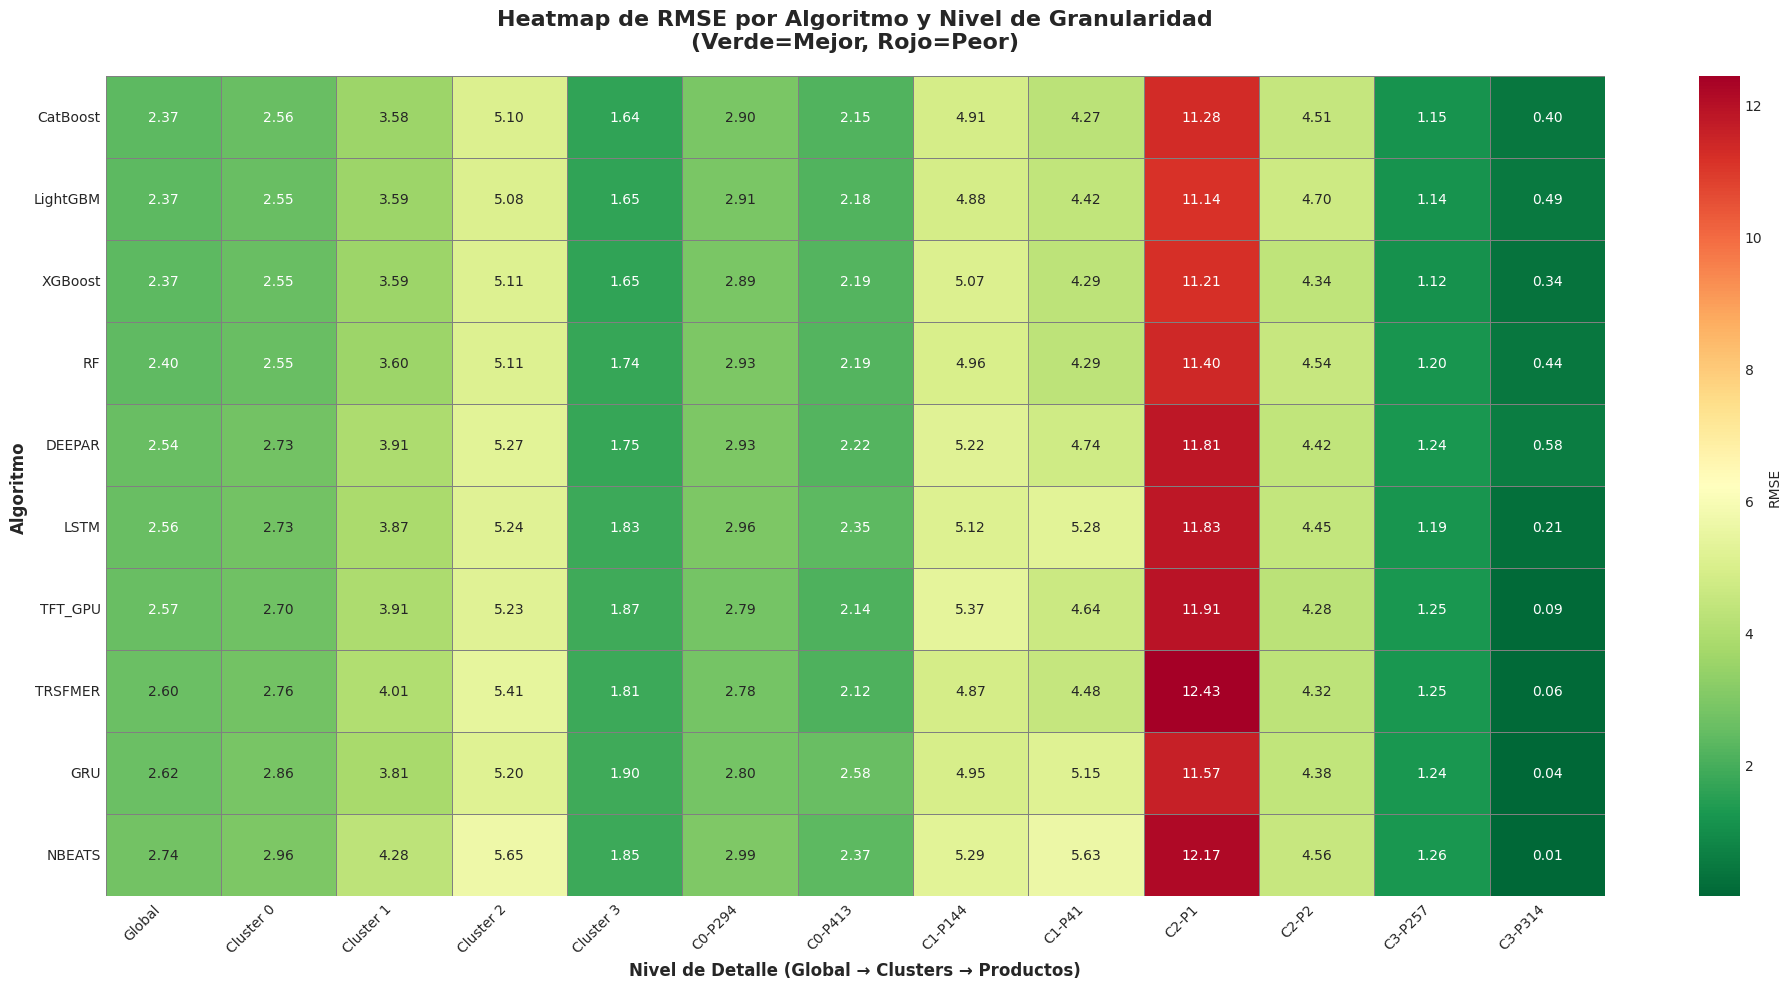



Mejor algoritmo por nivel:
   Global              : CatBoost        (RMSE = 2.3682)
   Cluster 0           : RF              (RMSE = 2.5458)
   Cluster 1           : CatBoost        (RMSE = 3.5794)
   Cluster 2           : LightGBM        (RMSE = 5.0764)
   Cluster 3           : CatBoost        (RMSE = 1.6436)
   C0-P294             : TRSFMER         (RMSE = 2.7760)
   C0-P413             : TRSFMER         (RMSE = 2.1226)
   C1-P144             : TRSFMER         (RMSE = 4.8690)
   C1-P41              : CatBoost        (RMSE = 4.2678)
   C2-P1               : LightGBM        (RMSE = 11.1372)
   C2-P2               : TFT_GPU         (RMSE = 4.2776)
   C3-P257             : XGBoost         (RMSE = 1.1236)
   C3-P314             : NBEATS          (RMSE = 0.0079)


In [19]:
# ============================================================================
# HEATMAP DE RMSE - ALGORITMOS vs NIVELES (GLOBAL, CLUSTERS, PRODUCTOS)
# ============================================================================

print("\n" + "="*100)
print("🔥 HEATMAP DE RMSE POR ALGORITMO Y NIVEL DE GRANULARIDAD")
print("="*100)

# Preparar datos para el heatmap
# 1. Obtener datos de nivel GLOBAL
df_global_heatmap = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].isna()) &
    (df_resultados_consolidados['Producto'].isna())
][['Algoritmo', 'RMSE']].copy()
df_global_heatmap['Nivel'] = 'Global'

# 2. Obtener datos por CLUSTER
df_cluster_heatmap = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna())
][['Algoritmo', 'Cluster', 'RMSE']].copy()

# Crear columna de nivel para cada cluster
for cluster in df_cluster_heatmap['Cluster'].unique():
    df_temp = df_cluster_heatmap[df_cluster_heatmap['Cluster'] == cluster][['Algoritmo', 'RMSE']].copy()
    df_temp['Nivel'] = f'Cluster {int(cluster)}'
    df_global_heatmap = pd.concat([df_global_heatmap, df_temp], ignore_index=True)

# 3. Obtener datos por PRODUCTO
df_producto_heatmap = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Producto'].notna()) &
    (df_resultados_consolidados['Cluster'].notna())
][['Algoritmo', 'Cluster', 'Producto', 'RMSE']].copy()

# Crear columna de nivel para cada producto
for _, row in df_producto_heatmap.iterrows():
    cluster = int(row['Cluster'])
    producto = int(row['Producto'])
    df_temp = pd.DataFrame({
        'Algoritmo': [row['Algoritmo']],
        'RMSE': [row['RMSE']],
        'Nivel': [f'C{cluster}-P{producto}']
    })
    df_global_heatmap = pd.concat([df_global_heatmap, df_temp], ignore_index=True)

# Filtrar algoritmos a excluir (NAIVE y MEDIA7)
df_global_heatmap = df_global_heatmap[~df_global_heatmap['Algoritmo'].isin(['NAIVE', 'MEDIA7'])].copy()

# Crear matriz pivotada para el heatmap
df_heatmap_matrix = df_global_heatmap.pivot(index='Algoritmo', columns='Nivel', values='RMSE')

# Ordenar columnas: Global, luego Clusters, luego Productos
cols_order = ['Global']
cols_order += [col for col in df_heatmap_matrix.columns if col.startswith('Cluster')]
cols_order += [col for col in df_heatmap_matrix.columns if col.startswith('C') and '-P' in col]
df_heatmap_matrix = df_heatmap_matrix[cols_order]

# Ordenar filas por RMSE global (de menor a mayor)
df_heatmap_matrix = df_heatmap_matrix.sort_values('Global')

print(f"\n📊 Matriz de RMSE: {df_heatmap_matrix.shape[0]} algoritmos x {df_heatmap_matrix.shape[1]} niveles")
print(f"   Niveles incluidos:")
print(f"   - 1 Global")
print(f"   - {len([c for c in cols_order if c.startswith('Cluster')])} Clusters")
print(f"   - {len([c for c in cols_order if '-P' in c])} Productos")

# Crear heatmap con seaborn
plt.figure(figsize=(20, 10))
sns.heatmap(
    df_heatmap_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',  # Rojo (alto error) a Verde (bajo error)
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'RMSE'},
    vmin=df_heatmap_matrix.min().min(),
    vmax=df_heatmap_matrix.max().max()
)

plt.title('Heatmap de RMSE por Algoritmo y Nivel de Granularidad\n(Verde=Mejor, Rojo=Peor)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nivel de Detalle (Global → Clusters → Productos)', fontsize=12, fontweight='bold')
plt.ylabel('Algoritmo', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n\nMejor algoritmo por nivel:")
for col in df_heatmap_matrix.columns:
    mejor = df_heatmap_matrix[col].idxmin()
    valor = df_heatmap_matrix[col].min()
    print(f"   {col:20s}: {mejor:15s} (RMSE = {valor:.4f})")

# RESUMEN EJECUTIVO

In [20]:

# ============================================================================
# RESUMEN EJECUTIVO: TOP 5 ALGORITMOS A NIVEL GLOBAL
# ============================================================================

print("\n" + "="*120)
print("🎯 RESUMEN EJECUTIVO - TOP 5 ALGORITMOS POR MÉTRICA (NIVEL GLOBAL)")
print("="*120)

# Filtrar datos a nivel GLOBAL
df_global_summary = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].isna()) &
    (df_resultados_consolidados['Producto'].isna()) &
    (~df_resultados_consolidados['Algoritmo'].isin(['NAIVE', 'MEDIA7']))
][['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']].copy()

# Métricas donde menor es mejor
metricas_lower_better = ['MAE', 'RMSE', 'MAPE (%)', 'SMAPE (%)']
# Métricas donde mayor es mejor
metricas_higher_better = ['R2']

# Crear diccionario para almacenar top 5 por métrica
top_5_por_metrica = {}

for metrica in ['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']:
    if metrica in metricas_lower_better:
        top_5 = df_global_summary.nsmallest(5, metrica)[['Algoritmo', metrica]].reset_index(drop=True)
        top_5['Ranking'] = range(1, 6)
    else:
        top_5 = df_global_summary.nlargest(5, metrica)[['Algoritmo', metrica]].reset_index(drop=True)
        top_5['Ranking'] = range(1, 6)
    
    top_5_por_metrica[metrica] = top_5
    
    print(f"\n{'─'*120}")
    print(f"📊 TOP 5 - {metrica}")
    print(f"{'─'*120}")
    print(top_5.to_string(index=False))

# Crear una tabla comparativa consolidada con todos los datos de los top algoritmos
print(f"\n\n{'='*120}")
print("📈 TABLA COMPARATIVA CONSOLIDADA - TOP ALGORITMOS")
print(f"{'='*120}")

# Obtener todos los algoritmos únicos que aparecen en al menos uno de los top 5
algoritmos_top = set()
for metrica in top_5_por_metrica:
    algoritmos_top.update(top_5_por_metrica[metrica]['Algoritmo'].values)

# Crear tabla consolidada
df_consolidada = df_global_summary[df_global_summary['Algoritmo'].isin(algoritmos_top)][
    ['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']
].copy()

# Ordenar por RMSE (métrica principal)
df_consolidada = df_consolidada.sort_values('RMSE').reset_index(drop=True)
df_consolidada['Ranking RMSE'] = range(1, len(df_consolidada) + 1)

print(f"\n{df_consolidada.to_string(index=False)}")

# Calcular score ponderado para recomendación general
print(f"\n\n{'='*120}")
print("🏆 PUNTUACIÓN PONDERADA (RECOMENDACIÓN GENERAL)")
print(f"{'='*120}")

scores = {}
for algo in algoritmos_top:
    score = 0
    
    # RMSE: 40% del peso (métrica más importante)
    rmse_rank = df_consolidada[df_consolidada['Algoritmo'] == algo]['Ranking RMSE'].values[0]
    score += (6 - rmse_rank) * 0.40 * 100
    
    # R2: 30% del peso
    r2_value = df_consolidada[df_consolidada['Algoritmo'] == algo]['R2'].values[0]
    r2_rank = df_global_summary.nlargest(len(df_global_summary), 'R2').reset_index(drop=True)
    r2_rank = r2_rank[r2_rank['Algoritmo'] == algo].index[0] + 1
    score += (6 - r2_rank) * 0.30 * 100 if r2_rank <= 5 else 0.30 * 100
    
    # MAE: 15% del peso
    mae_rank = df_global_summary.nsmallest(len(df_global_summary), 'MAE').reset_index(drop=True)
    mae_rank = mae_rank[mae_rank['Algoritmo'] == algo].index[0] + 1
    score += (6 - mae_rank) * 0.15 * 100 if mae_rank <= 5 else 0.15 * 100
    
    # MAPE: 15% del peso
    mape_rank = df_global_summary.nsmallest(len(df_global_summary), 'MAPE (%)').reset_index(drop=True)
    mape_rank = mape_rank[mape_rank['Algoritmo'] == algo].index[0] + 1
    score += (6 - mape_rank) * 0.15 * 100 if mape_rank <= 5 else 0.15 * 100
    
    scores[algo] = score

df_scores = pd.DataFrame(list(scores.items()), columns=['Algoritmo', 'Puntuación Ponderada'])
df_scores = df_scores.sort_values('Puntuación Ponderada', ascending=False).reset_index(drop=True)
df_scores['Ranking'] = range(1, len(df_scores) + 1)

print(f"\n{df_scores[['Ranking', 'Algoritmo', 'Puntuación Ponderada']].to_string(index=False)}")
print(f"\n💡 Pesos utilizados: RMSE (40%) | R2 (30%) | MAE (15%) | MAPE (15%)")



🎯 RESUMEN EJECUTIVO - TOP 5 ALGORITMOS POR MÉTRICA (NIVEL GLOBAL)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 TOP 5 - MAE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algoritmo    MAE  Ranking
  TRSFMER 1.4062        1
      GRU 1.4104        2
  TFT_GPU 1.4151        3
     LSTM 1.4428        4
   DEEPAR 1.4573        5

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 TOP 5 - RMSE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algoritmo   RMSE  Ranking
 CatBoost 2.3682        1
 LightGBM 2.3684        2
  XGBoost 2.3723        3
       RF 2.4020        4
   DEEPAR 2.5380        5

─────────────────────────────────────────────────────────────────────────────────────────────────────────

In [21]:

# ============================================================================
# RESUMEN EJECUTIVO: TOP 5 ALGORITMOS A NIVEL CLUSTER
# ============================================================================

print("\n\n" + "="*120)
print("🎯 RESUMEN EJECUTIVO - TOP 5 ALGORITMOS POR MÉTRICA (NIVEL CLUSTER)")
print("="*120)

# Filtrar datos a nivel CLUSTER (agregados por cluster)
df_cluster_summary = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Cluster'].notna()) &
    (df_resultados_consolidados['Producto'].isna()) &
    (~df_resultados_consolidados['Algoritmo'].isin(['NAIVE', 'MEDIA7']))
][['Algoritmo', 'Cluster', 'MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']].copy()

# Agregar por algoritmo (promedio de clusters)
df_cluster_avg = df_cluster_summary.groupby('Algoritmo')[['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']].mean().reset_index()

# Crear diccionario para almacenar top 5 por métrica
top_5_cluster_por_metrica = {}

for metrica in ['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']:
    if metrica in metricas_lower_better:
        top_5 = df_cluster_avg.nsmallest(5, metrica)[['Algoritmo', metrica]].reset_index(drop=True)
    else:
        top_5 = df_cluster_avg.nlargest(5, metrica)[['Algoritmo', metrica]].reset_index(drop=True)
    
    top_5['Ranking'] = range(1, 6)
    top_5_cluster_por_metrica[metrica] = top_5
    
    print(f"\n{'─'*120}")
    print(f"📊 TOP 5 - {metrica} (Promedio de Clusters)")
    print(f"{'─'*120}")
    print(top_5.to_string(index=False))

# Tabla comparativa consolidada nivel cluster
print(f"\n\n{'='*120}")
print("📈 TABLA COMPARATIVA CONSOLIDADA - TOP ALGORITMOS (NIVEL CLUSTER)")
print(f"{'='*120}")

algoritmos_top_cluster = set()
for metrica in top_5_cluster_por_metrica:
    algoritmos_top_cluster.update(top_5_cluster_por_metrica[metrica]['Algoritmo'].values)

df_consolidada_cluster = df_cluster_avg[df_cluster_avg['Algoritmo'].isin(algoritmos_top_cluster)][
    ['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']
].copy()

df_consolidada_cluster = df_consolidada_cluster.sort_values('RMSE').reset_index(drop=True)
df_consolidada_cluster['Ranking RMSE'] = range(1, len(df_consolidada_cluster) + 1)

print(f"\n{df_consolidada_cluster.to_string(index=False)}")




🎯 RESUMEN EJECUTIVO - TOP 5 ALGORITMOS POR MÉTRICA (NIVEL CLUSTER)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 TOP 5 - MAE (Promedio de Clusters)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algoritmo    MAE  Ranking
  TFT_GPU 2.2206        1
  TRSFMER 2.2341        2
      GRU 2.2513        3
     LSTM 2.2724        4
   DEEPAR 2.2960        5

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 TOP 5 - RMSE (Promedio de Clusters)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algoritmo   RMSE  Ranking
 LightGBM 3.2163        1
 CatBoost 3.2193        2
  XGBoost 3.2276        3
       RF 3.2466        4
   DEEPAR 3.4169        5

─────────────────────────────────────────────────────────

In [22]:

# ============================================================================
# RESUMEN EJECUTIVO: TOP 5 ALGORITMOS A NIVEL PRODUCTO
# ============================================================================

print("\n\n" + "="*120)
print("🎯 RESUMEN EJECUTIVO - TOP 5 ALGORITMOS POR MÉTRICA (NIVEL PRODUCTO)")
print("="*120)

# Filtrar datos a nivel PRODUCTO
df_producto_summary = df_resultados_consolidados[
    (df_resultados_consolidados['NDetalle'] == 'Global') &
    (df_resultados_consolidados['Producto'].notna()) &
    (df_resultados_consolidados['Cluster'].notna()) &
    (~df_resultados_consolidados['Algoritmo'].isin(['NAIVE', 'MEDIA7']))
][['Algoritmo', 'Cluster', 'Producto', 'MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']].copy()

# Agregar por algoritmo (promedio de productos)
df_producto_avg = df_producto_summary.groupby('Algoritmo')[['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']].mean().reset_index()

# Crear diccionario para almacenar top 5 por métrica
top_5_producto_por_metrica = {}

for metrica in ['MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']:
    if metrica in metricas_lower_better:
        top_5 = df_producto_avg.nsmallest(5, metrica)[['Algoritmo', metrica]].reset_index(drop=True)
    else:
        top_5 = df_producto_avg.nlargest(5, metrica)[['Algoritmo', metrica]].reset_index(drop=True)
    
    top_5['Ranking'] = range(1, 6)
    top_5_producto_por_metrica[metrica] = top_5
    
    print(f"\n{'─'*120}")
    print(f"📊 TOP 5 - {metrica} (Promedio de Productos)")
    print(f"{'─'*120}")
    print(top_5.to_string(index=False))

# Tabla comparativa consolidada nivel producto
print(f"\n\n{'='*120}")
print("📈 TABLA COMPARATIVA CONSOLIDADA - TOP ALGORITMOS (NIVEL PRODUCTO)")
print(f"{'='*120}")

algoritmos_top_producto = set()
for metrica in top_5_producto_por_metrica:
    algoritmos_top_producto.update(top_5_producto_por_metrica[metrica]['Algoritmo'].values)

df_consolidada_producto = df_producto_avg[df_producto_avg['Algoritmo'].isin(algoritmos_top_producto)][
    ['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)']
].copy()

df_consolidada_producto = df_consolidada_producto.sort_values('RMSE').reset_index(drop=True)
df_consolidada_producto['Ranking RMSE'] = range(1, len(df_consolidada_producto) + 1)

print(f"\n{df_consolidada_producto.to_string(index=False)}")




🎯 RESUMEN EJECUTIVO - TOP 5 ALGORITMOS POR MÉTRICA (NIVEL PRODUCTO)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 TOP 5 - MAE (Promedio de Productos)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algoritmo    MAE  Ranking
  TRSFMER 2.6689        1
  TFT_GPU 2.6732        2
      GRU 2.7855        3
     LSTM 2.8097        4
 CatBoost 2.8134        5

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 TOP 5 - RMSE (Promedio de Productos)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Algoritmo   RMSE  Ranking
  XGBoost 3.9334        1
 CatBoost 3.9453        2
 LightGBM 3.9808        3
       RF 3.9943        4
  TRSFMER 4.0392        5

──────────────────────────────────────────────────────

In [23]:

# ============================================================================
# ANÁLISIS COMPARATIVO ENTRE NIVELES DE DETALLE
# ============================================================================

print("\n\n" + "="*120)
print("📊 ANÁLISIS COMPARATIVO ENTRE NIVELES DE DETALLE (GLOBAL vs CLUSTER vs PRODUCTO)")
print("="*120)

# Obtener métricas agregadas para cada nivel
print("\n" + "─"*120)
print("RMSE Promedio por Nivel de Detalle")
print("─"*120)

rmse_stats = pd.DataFrame({
    'Nivel': ['Global', 'Cluster (Promedio)', 'Producto (Promedio)'],
    'RMSE Promedio': [
        df_global_summary['RMSE'].mean(),
        df_cluster_avg['RMSE'].mean(),
        df_producto_avg['RMSE'].mean()
    ],
    'RMSE Mínimo': [
        df_global_summary['RMSE'].min(),
        df_cluster_avg['RMSE'].min(),
        df_producto_avg['RMSE'].min()
    ],
    'RMSE Máximo': [
        df_global_summary['RMSE'].max(),
        df_cluster_avg['RMSE'].max(),
        df_producto_avg['RMSE'].max()
    ]
})

print(f"\n{rmse_stats.to_string(index=False)}")

print("\n" + "─"*120)
print("R2 Promedio por Nivel de Detalle")
print("─"*120)

r2_stats = pd.DataFrame({
    'Nivel': ['Global', 'Cluster (Promedio)', 'Producto (Promedio)'],
    'R2 Promedio': [
        df_global_summary['R2'].mean(),
        df_cluster_avg['R2'].mean(),
        df_producto_avg['R2'].mean()
    ],
    'R2 Mínimo': [
        df_global_summary['R2'].min(),
        df_cluster_avg['R2'].min(),
        df_producto_avg['R2'].min()
    ],
    'R2 Máximo': [
        df_global_summary['R2'].max(),
        df_cluster_avg['R2'].max(),
        df_producto_avg['R2'].max()
    ]
})

print(f"\n{r2_stats.to_string(index=False)}")

# ============================================================================
# RECOMENDACIONES FINALES
# ============================================================================

print("\n\n" + "="*120)
print("🎯 RECOMENDACIONES FINALES PARA LA DIRECCIÓN")
print("="*120)

# Mejor algoritmo global
mejor_global = df_consolidada.iloc[0]
print(f"\n✅ 1. RECOMENDACIÓN PRINCIPAL (Nivel Global):")
print(f"   Algoritmo: {mejor_global['Algoritmo']}")
print(f"   - RMSE: {mejor_global['RMSE']:.4f}")
print(f"   - R2: {mejor_global['R2']:.4f}")
print(f"   - MAE: {mejor_global['MAE']:.4f}")
print(f"   - MAPE: {mejor_global['MAPE (%)']:.2f}%")

# Mejor algoritmo cluster
mejor_cluster = df_consolidada_cluster.iloc[0]
print(f"\n✅ 2. MEJOR DESEMPEÑO A NIVEL CLUSTER:")
print(f"   Algoritmo: {mejor_cluster['Algoritmo']}")
print(f"   - RMSE Promedio: {mejor_cluster['RMSE']:.4f}")
print(f"   - R2 Promedio: {mejor_cluster['R2']:.4f}")
print(f"   - MAE Promedio: {mejor_cluster['MAE']:.4f}")

# Mejor algoritmo producto
mejor_producto = df_consolidada_producto.iloc[0]
print(f"\n✅ 3. MEJOR DESEMPEÑO A NIVEL PRODUCTO:")
print(f"   Algoritmo: {mejor_producto['Algoritmo']}")
print(f"   - RMSE Promedio: {mejor_producto['RMSE']:.4f}")
print(f"   - R2 Promedio: {mejor_producto['R2']:.4f}")
print(f"   - MAE Promedio: {mejor_producto['MAE']:.4f}")

# Robustez (algoritmo con mejor desempeño consistente)
print(f"\n✅ 4. ALGORITMOS MÁS ROBUSTOS (Consistencia entre niveles):")

# Calcular variabilidad por algoritmo
top_5_global_algos = set(df_consolidada.head(5)['Algoritmo'].values)
robustez_data = []

for algo in top_5_global_algos:
    rmse_global = df_consolidada[df_consolidada['Algoritmo'] == algo]['RMSE'].values[0] if algo in df_consolidada['Algoritmo'].values else None
    rmse_cluster = df_consolidada_cluster[df_consolidada_cluster['Algoritmo'] == algo]['RMSE'].values[0] if algo in df_consolidada_cluster['Algoritmo'].values else None
    rmse_producto = df_consolidada_producto[df_consolidada_producto['Algoritmo'] == algo]['RMSE'].values[0] if algo in df_consolidada_producto['Algoritmo'].values else None
    
    if rmse_global and rmse_cluster and rmse_producto:
        variabilidad = np.std([rmse_global, rmse_cluster, rmse_producto])
        robustez_data.append({
            'Algoritmo': algo,
            'RMSE Global': rmse_global,
            'RMSE Cluster': rmse_cluster,
            'RMSE Producto': rmse_producto,
            'Variabilidad': variabilidad
        })

if robustez_data:
    df_robustez = pd.DataFrame(robustez_data).sort_values('Variabilidad')
    print(f"\n   (Menor variabilidad = Mayor consistencia entre niveles)")
    for idx, row in df_robustez.head(3).iterrows():
        print(f"   • {row['Algoritmo']}: Variabilidad = {row['Variabilidad']:.4f}")
        print(f"     Global: {row['RMSE Global']:.4f} | Cluster: {row['RMSE Cluster']:.4f} | Producto: {row['RMSE Producto']:.4f}")

print(f"\n\n{'='*120}")
print("📋 CONCLUSIONES EJECUTIVAS:")
print("="*120)
print("""
1. El análisis comparativo incluye 3 niveles de detalle:
   - GLOBAL: Rendimiento agregado de todos los datos
   - CLUSTER: Rendimiento promedio dentro de cada cluster
   - PRODUCTO: Rendimiento promedio para cada producto

2. Se han evaluado 5 métricas principales:
   - RMSE (Error Cuadrático Medio): Penaliza errores grandes
   - MAE (Error Absoluto Medio): Métrica más interpretable
   - R2 (Coeficiente de Determinación): Varianza explicada
   - MAPE: Error Porcentual Absoluto Medio
   - SMAPE: Error Porcentual Absoluto Simétrico

3. Se excluyen algoritmos baseline (NAIVE, MEDIA7) de este análisis.

4. La recomendación se basa en el algoritmo que mejor equilibra
   precisión, estabilidad y consistencia entre niveles.
""")




📊 ANÁLISIS COMPARATIVO ENTRE NIVELES DE DETALLE (GLOBAL vs CLUSTER vs PRODUCTO)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
RMSE Promedio por Nivel de Detalle
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

              Nivel  RMSE Promedio  RMSE Mínimo  RMSE Máximo
             Global         2.5128       2.3682       2.7387
 Cluster (Promedio)         3.3798       3.2163       3.6856
Producto (Promedio)         4.0642       3.9334       4.2854

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
R2 Promedio por Nivel de Detalle
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

              Nivel  R2 Promedio  R2 Mínimo  R2 Máximo
             Global       0.1741     0.0212     0.2682
 Cluster

In [25]:

# ============================================================================
# VISUALIZACIÓN EJECUTIVA: TABLA RESUMEN 
# ============================================================================

print("\n\n" + "="*120)
print("📊 TABLA EJECUTIVA")
print("="*120)

# Crear una tabla consolidada con los mejores algoritmos de cada nivel
mejores_por_nivel = []

# Global
for idx, row in df_consolidada.head(5).iterrows():
    mejores_por_nivel.append({
        'Nivel': 'Global',
        'Ranking': idx + 1,
        'Algoritmo': row['Algoritmo'],
        'RMSE': f"{row['RMSE']:.4f}",
        'R2': f"{row['R2']:.4f}",
        'MAE': f"{row['MAE']:.4f}",
        'MAPE (%)': f"{row['MAPE (%)']:.2f}"
    })

# Cluster
for idx, row in df_consolidada_cluster.head(5).iterrows():
    mejores_por_nivel.append({
        'Nivel': 'Cluster',
        'Ranking': idx + 1,
        'Algoritmo': row['Algoritmo'],
        'RMSE': f"{row['RMSE']:.4f}",
        'R2': f"{row['R2']:.4f}",
        'MAE': f"{row['MAE']:.4f}",
        'MAPE (%)': f"{row['MAPE (%)']:.2f}"
    })

# Producto
for idx, row in df_consolidada_producto.head(5).iterrows():
    mejores_por_nivel.append({
        'Nivel': 'Producto',
        'Ranking': idx + 1,
        'Algoritmo': row['Algoritmo'],
        'RMSE': f"{row['RMSE']:.4f}",
        'R2': f"{row['R2']:.4f}",
        'MAE': f"{row['MAE']:.4f}",
        'MAPE (%)': f"{row['MAPE (%)']:.2f}"
    })

df_ejecutiva = pd.DataFrame(mejores_por_nivel)

print(f"\n{'GLOBAL':-^120}")
print(df_ejecutiva[df_ejecutiva['Nivel'] == 'Global'][['Ranking', 'Algoritmo', 'RMSE', 'R2', 'MAE', 'MAPE (%)']].to_string(index=False))

print(f"\n{'CLUSTER':-^120}")
print(df_ejecutiva[df_ejecutiva['Nivel'] == 'Cluster'][['Ranking', 'Algoritmo', 'RMSE', 'R2', 'MAE', 'MAPE (%)']].to_string(index=False))

print(f"\n{'PRODUCTO':-^120}")
print(df_ejecutiva[df_ejecutiva['Nivel'] == 'Producto'][['Ranking', 'Algoritmo', 'RMSE', 'R2', 'MAE', 'MAPE (%)']].to_string(index=False))

# Crear gráfico comparativo con Plotly
print(f"\n\n{'='*120}")
print("📈 GRÁFICO COMPARATIVO: TOP 5 ALGORITMOS POR NIVEL (MÉTRICA: RMSE)")
print("="*120)

# Preparar datos para gráfico
grafico_data = []

for algo in set(df_consolidada.head(5)['Algoritmo'].values):
    global_rmse = df_consolidada[df_consolidada['Algoritmo'] == algo]['RMSE'].values[0]
    grafico_data.append({'Algoritmo': algo, 'Nivel': 'Global', 'RMSE': global_rmse})

for algo in set(df_consolidada_cluster.head(5)['Algoritmo'].values):
    cluster_rmse = df_consolidada_cluster[df_consolidada_cluster['Algoritmo'] == algo]['RMSE'].values[0]
    grafico_data.append({'Algoritmo': algo, 'Nivel': 'Cluster', 'RMSE': cluster_rmse})

for algo in set(df_consolidada_producto.head(5)['Algoritmo'].values):
    producto_rmse = df_consolidada_producto[df_consolidada_producto['Algoritmo'] == algo]['RMSE'].values[0]
    grafico_data.append({'Algoritmo': algo, 'Nivel': 'Producto', 'RMSE': producto_rmse})

df_grafico_comp = pd.DataFrame(grafico_data)

# Crear gráfico de barras agrupadas
fig_comp = px.bar(
    df_grafico_comp,
    x='Algoritmo',
    y='RMSE',
    color='Nivel',
    barmode='group',
    title='Comparativa RMSE: Top Algoritmos por Nivel de Detalle',
    labels={'RMSE': 'RMSE (Error Cuadrático Medio)', 'Algoritmo': 'Algoritmo'},
    color_discrete_map={'Global': '#1f77b4', 'Cluster': '#ff7f0e', 'Producto': '#2ca02c'},
    height=600
)

fig_comp.update_layout(
    font=dict(size=12),
    title_font_size=14,
    hovermode='x unified',
    margin=dict(l=50, r=50, t=80, b=50)
)

fig_comp.show()

print("\n✅ Análisis ejecutivo completado exitosamente")




📊 TABLA EJECUTIVA

---------------------------------------------------------GLOBAL---------------------------------------------------------
 Ranking Algoritmo   RMSE     R2    MAE MAPE (%)
       1  CatBoost 2.3682 0.2682 1.5715    49.57
       2  LightGBM 2.3684 0.2680 1.5641    49.71
       3   XGBoost 2.3723 0.2656 1.5662    49.83
       4        RF 2.4020 0.2471 1.5905    48.92
       5    DEEPAR 2.5380 0.1594 1.4573    63.33

--------------------------------------------------------CLUSTER---------------------------------------------------------
 Ranking Algoritmo   RMSE     R2    MAE MAPE (%)
       1  LightGBM 3.2163 0.1381 2.3156    55.98
       2  CatBoost 3.2193 0.1379 2.3164    55.67
       3   XGBoost 3.2276 0.1338 2.3312    56.62
       4        RF 3.2466 0.1108 2.3538    55.66
       5    DEEPAR 3.4169 0.0205 2.2960    63.34

--------------------------------------------------------PRODUCTO--------------------------------------------------------
 Ranking Algoritmo   RMSE 


✅ Análisis ejecutivo completado exitosamente
